## Composite silhouette $S_{mM}$

In [1]:
import numpy as np
import pandas as pd

from sklearn.cluster import KMeans, MiniBatchKMeans, Birch, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_samples
from sklearn.utils import resample

import matplotlib.pyplot as plt
from joblib import Parallel, delayed


def _fit_predict_labels(X, k, seed, algo="gmm", kmeans_n_init=1, mb_batch_size=1024):
    algo = str(algo).lower()
    k = int(k)

    if algo == "kmeans":
        model = KMeans(n_clusters=k, random_state=int(seed), n_init=int(kmeans_n_init))
        return model.fit_predict(X)

    if algo in ("minibatchkmeans", "mbkmeans", "mbk"):
        model = MiniBatchKMeans(
            n_clusters=k,
            random_state=int(seed),
            n_init=int(kmeans_n_init),
            batch_size=int(mb_batch_size),
        )
        return model.fit_predict(X)

    if algo == "birch":
        model = Birch(n_clusters=k)
        return model.fit_predict(X)

    if algo in ("agglomerative", "agg"):
        # ward requires Euclidean
        model = AgglomerativeClustering(n_clusters=k, linkage="ward")
        return model.fit_predict(X)

    if algo in ("gmm", "gaussianmixture"):
        model = GaussianMixture(
            n_components=k,
            random_state=int(seed),
            covariance_type="full",
            init_params="kmeans",
            n_init=1,
        )
        return model.fit_predict(X)

    raise ValueError(f"Unknown algo='{algo}'. Supported: kmeans, minibatchkmeans, birch, agglomerative, gmm.")

class CompSil:
    """
    Composite Silhouette (CompSil)

    Per subsample b=1..B for each k:
      - compute S_micro^(b), S_macro^(b)
      - Δ_b = S_micro^(b) - S_macro^(b)
      - D = max_b |Δ_b|
      - r_raw_b = Δ_b/(D+eps) in [-1,1]
      - r_b = tanh(r_raw_b)
      - w_b = (1+r_b)/2
      - S_mM^(b) = w_b*S_micro^(b) + (1-w_b)*S_macro^(b)

    Aggregate for each k:
      - mean score:   S_mM(k)  = mean_b S_mM^(b)
      - std score:    std_S_mM(k) = std_b  S_mM^(b)
      - standard error: se_S_mM(k) = std_S_mM(k) / sqrt(B_eff)
      - lower conf bound: LCB_S_mM(k) = S_mM(k) - se_S_mM(k)

    Selection:
      - k* = argmax_k S_mM(k) (or argmax_k LCB_S_mM(k))

    Sampling size mechanism:
      - explicit `sample_size` (int), or
      - sample_size=None or sample_size="auto", the class chooses a subsample size automatically
        based on dataset size N and the maximum k in `k_values`.

    Parameters:
    - data: ndarray or DataFrame, shape (n_samples, n_features)
    - ground_truth: int, optional
    - k_values: iterable or int, default=range(2, 11)
    - num_samples: int, default=100  (B)
    - sample_size: int | float | None | "auto", default=1000
        * int: absolute subsample size m
        * float in (0,1]: treated as fraction f, m = floor(f*N)
        * None or "auto": compute m automatically (see _auto_sample_size)
    - random_state: int, default=42
    - n_jobs: int, default=-1
    - eps: float, default=1e-12
    - algo: str, default="kmeans"
        one of {"kmeans","minibatchkmeans","birch","agglomerative","gmm"}
    - kmeans_n_init: int, default=1
        used for kmeans / minibatchkmeans
    - mb_batch_size: int, default=1024
        used for minibatchkmeans
    """

    def __init__(self,
                 data,
                 ground_truth=None,
                 k_values=range(2, 11),
                 num_samples=10,
                 sample_size="auto",
                 random_state=42,
                 n_jobs=-1,
                 eps=1e-12,
                 algo="gmm",
                 kmeans_n_init=1,
                 mb_batch_size=1024):
        self.data = data
        self.ground_truth = ground_truth
        self.k_values = [k_values] if isinstance(k_values, int) else list(k_values)
        self.num_samples = int(num_samples)
        self.random_state = int(random_state)
        self.n_jobs = int(n_jobs)
        self.eps = float(eps)

        self.algo = str(algo).lower()
        self.kmeans_n_init = int(kmeans_n_init)
        self.mb_batch_size = int(mb_batch_size)

        self._results = []
        self.results_df = pd.DataFrame()
        self.score_ = None  # set only if one k is evaluated

        self.n_samples_ = int(len(self.data))
        if self.n_samples_ <= 0:
            raise ValueError("Empty dataset.")

        self.sample_size = self._resolve_sample_size(sample_size)
        self.sample_fraction_ = self.sample_size / self.n_samples_

        if self.sample_size < 2:
            raise ValueError(f"Resolved sample_size={self.sample_size} is too small.")
        if self.sample_size > self.n_samples_:
            raise ValueError(
                f"Resolved sample_size={self.sample_size} is larger than n_samples={self.n_samples_}."
            )

    def _resolve_sample_size(self, sample_size):
        n = self.n_samples_

        # Auto
        if sample_size is None or (isinstance(sample_size, str) and sample_size.lower() == "auto"):
            return self._auto_sample_size()

        # Fraction mode (float in (0,1])
        if isinstance(sample_size, float):
            if not (0.0 < sample_size <= 1.0):
                raise ValueError("If sample_size is a float, it must be in (0, 1].")
            m = int(np.floor(sample_size * n))
            return max(2, min(m, n))

        # Int mode
        m = int(sample_size)
        return m

    def _auto_sample_size(self):
        """
        Automatic subsample size selection (no user-facing hyperparameters).

        Heuristic:
          1) Ensure a minimum average points-per-cluster at k_max: m >= 30 * k_max
          2) Use a baseline fraction depending on dataset size:
             - small N: 0.8N
             - medium N: 0.6N
             - large N: 0.4N
          3) Take the maximum of (1) and (2), then cap at N.
        """
        n = self.n_samples_
        k_max = int(max(self.k_values)) if len(self.k_values) > 0 else 2

        m_min = 30 * k_max

        if n <= 2000:
            m_base = int(np.floor(0.80 * n))
        elif n <= 20000:
            m_base = int(np.floor(0.60 * n))
        else:
            m_base = int(np.floor(0.40 * n))

        m = max(m_min, m_base)
        m = min(max(2, m), n)
        return m

    def evaluate_sample(self, k, i):
        """
        One subsampling iteration for fixed k.
        Returns: (smicro, smacro, diff, s_mm_b)
        """
        seed = self.random_state + i

        sampled_data = resample(
            self.data,
            n_samples=self.sample_size,
            replace=False,
            random_state=seed
        )

        labels = _fit_predict_labels(
            sampled_data,
            k=int(k),
            seed=int(seed),
            algo=self.algo,
            kmeans_n_init=self.kmeans_n_init,
            mb_batch_size=self.mb_batch_size,
        )

        try:
            s = silhouette_samples(sampled_data, labels)  # compute once

            # micro silhouette
            smicro = float(np.mean(s))

            labs = np.asarray(labels)
            uniq = np.unique(labs)
            cluster_means = [float(np.mean(s[labs == u])) for u in uniq]

            # macro silhouette
            smacro = float(np.mean(cluster_means)) if len(cluster_means) > 0 else np.nan
        except Exception:
            return np.nan, np.nan, np.nan, np.nan

        diff = smicro - smacro
        return smicro, smacro, diff, np.nan

    @staticmethod
    def _tanh_rb_weights_from_differences(differences, eps=1e-12):
        """
        Given Δ_b over b=1..B, compute:
          D       = max |Δ_b|
          r_raw_b = Δ_b/(D+eps) in [-1, 1]
          r_b     = tanh(r_raw_b)
          w_b     = (1+r_b)/2 in (0,1)
        """
        d = np.asarray(differences, dtype=float)
        finite = np.isfinite(d)

        if not np.any(finite):
            return d * np.nan, d * np.nan, np.nan

        D = float(np.max(np.abs(d[finite])))
        denom = D + float(eps)

        if D == 0.0:
            r = np.zeros_like(d)
            r[~finite] = np.nan
            w = 0.5 * np.ones_like(d)
            w[~finite] = np.nan
            return w, r, D

        r_raw = d / denom
        r_raw = np.clip(r_raw, -1.0, 1.0)
        r_raw[~finite] = np.nan

        r = np.tanh(r_raw)
        r[~finite] = np.nan

        w = 0.5 * (1.0 + r)
        w[~finite] = np.nan

        return w, r, D

    def evaluate(self):
        """
        Evaluate over k_values using subsampled clustering.
        Stores results in self.results_df.

        Output columns (per k):
        - avg S_micro
        - avg S_macro
        - w_micro (mean of per-subsample weights; descriptive)
        - S_mM (mean of per-subsample composites)
        - std S_mM
        - se S_mM
        - LCB S_mM  (S_mM - se)
        """
        self._results = []

        for k in self.k_values:
            results = Parallel(n_jobs=self.n_jobs)(
                delayed(self.evaluate_sample)(k, i) for i in range(self.num_samples)
            )

            smicro_list, smacro_list, differences, _ = zip(*results)

            smicro_arr = np.asarray(smicro_list, dtype=float)
            smacro_arr = np.asarray(smacro_list, dtype=float)
            diff_arr = np.asarray(differences, dtype=float)

            avg_smicro = float(np.nanmean(smicro_arr)) if np.any(np.isfinite(smicro_arr)) else np.nan
            avg_smacro = float(np.nanmean(smacro_arr)) if np.any(np.isfinite(smacro_arr)) else np.nan

            # weights
            w_b, r_b, D = self._tanh_rb_weights_from_differences(diff_arr, eps=self.eps)

            # per-subsample composite
            S_b = w_b * smicro_arr + (1.0 - w_b) * smacro_arr

            # mean composite
            S_mM = float(np.nanmean(S_b)) if np.any(np.isfinite(S_b)) else np.nan

            # descriptive mean weight
            w_micro_mean = float(np.nanmean(w_b)) if np.any(np.isfinite(w_b)) else np.nan

            # LCB components computed from S_b across valid subsamples
            finite_sb = np.isfinite(S_b)
            B_eff = int(np.sum(finite_sb))
            if B_eff >= 2:
                std_smm = float(np.nanstd(S_b, ddof=1))
                se_smm = std_smm / np.sqrt(B_eff)
            elif B_eff == 1:
                std_smm = 0.0
                se_smm = 0.0
            else:
                std_smm = np.nan
                se_smm = np.nan

            lcb_smm = (S_mM - se_smm) if (np.isfinite(S_mM) and np.isfinite(se_smm)) else np.nan

            if len(self.k_values) == 1:
                self.score_ = S_mM

            result = {
                'k': int(k),
                'avg S_micro': avg_smicro,
                'avg S_macro': avg_smacro,
                'w_micro': w_micro_mean,
                'S_mM': S_mM,
                'std S_mM': std_smm,
                'se S_mM': se_smm,
                'LCB S_mM': lcb_smm,
                'B_eff': B_eff,
                'sample_size': int(self.sample_size),
                'sample_fraction': float(self.sample_fraction_),
            }
            self._results.append(result)

        self.results_df = pd.DataFrame(self._results)

    def plot_results(self):
        """
        Plot S_mM and individual averages vs k.
        """
        if self.results_df.empty:
            raise ValueError("No results available. Run evaluate() first.")
        if len(self.results_df) == 1:
            raise ValueError("Cannot plot with only one k. Evaluate multiple k values.")

        max_smicro = self.results_df['avg S_micro'].max()
        max_smicro_k = self.results_df.loc[self.results_df['avg S_micro'].idxmax(), 'k']

        max_smacro = self.results_df['avg S_macro'].max()
        max_smacro_k = self.results_df.loc[self.results_df['avg S_macro'].idxmax(), 'k']

        max_smm = self.results_df['S_mM'].max()
        max_smm_k = self.results_df.loc[self.results_df['S_mM'].idxmax(), 'k']

        plt.figure(figsize=(10, 4))

        if self.ground_truth is not None:
            plt.axvline(
                x=self.ground_truth, color='red', linestyle='--', linewidth=2.5,
                label='Ground Truth'
            )

        plt.plot(
            self.results_df['k'], self.results_df['avg S_micro'],
            marker='o', linestyle='-', color='orange', linewidth=4, markersize=8, label='avg S_micro'
        )
        plt.plot(max_smicro_k, max_smicro, marker='*', color='orange', markersize=18)

        plt.plot(
            self.results_df['k'], self.results_df['avg S_macro'],
            marker='o', linestyle='-', color='blue', linewidth=4, markersize=8, label='avg S_macro'
        )
        plt.plot(max_smacro_k, max_smacro, marker='*', color='blue', markersize=18)

        plt.plot(
            self.results_df['k'], self.results_df['S_mM'],
            marker='o', linestyle='--', color='green', linewidth=4, markersize=8, label='S_mM'
        )
        plt.plot(max_smm_k, max_smm, marker='*', color='green', markersize=18)

        plt.xlabel('k', fontsize=15)
        plt.xticks(self.k_values, fontsize=14)
        plt.yticks(fontsize=14)
        plt.tick_params(axis='y', which='both', length=0)
        plt.grid(axis='y', linestyle='--')

        ax = plt.gca()
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['top'].set_visible(False)

        handles, labels = ax.get_legend_handles_labels()
        ax.legend(
            handles, labels,
            loc="lower left",
            bbox_to_anchor=(0, 1.02, 1, 0.2),
            mode="expand",
            ncol=len(labels),
            frameon=False,
            fontsize=12
        )

        plt.tight_layout()
        plt.show()

    def get_optimal_k(self, use_lcb=False):
        """
        Return optimal k.

        By default, uses max selection:
          k* = argmax_k (S_mM) (use_lcb for argmax_k (LCB S_mM) selection)

        """
        if self.results_df.empty:
            raise ValueError("No results available. Run evaluate() first.")

        if len(self.results_df) == 1:
            return int(self.results_df['k'].iloc[0])

        col = 'LCB S_mM' if use_lcb else 'S_mM'
        if col not in self.results_df.columns:
            raise ValueError(f"Missing column '{col}'. Run evaluate() first.")

        optimal_row = self.results_df.loc[self.results_df[col].idxmax()]
        return int(optimal_row['k'])

    def get_results_dataframe(self):
        """
        Return results DataFrame indexed by k.
        """
        if self.results_df.empty:
            raise ValueError("No results available. Run evaluate() first.")
        return self.results_df.set_index('k', inplace=False)

import numpy as np
import pandas as pd

from sklearn.cluster import KMeans, MiniBatchKMeans, Birch, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    calinski_harabasz_score,
    davies_bouldin_score,
)


def _fit_predict_labels(X, k, seed, algo="gmm", kmeans_n_init=1, mb_batch_size=1024):
    algo = str(algo).lower()
    k = int(k)

    if algo == "kmeans":
        model = KMeans(n_clusters=k, random_state=int(seed), n_init=int(kmeans_n_init))
        return model.fit_predict(X)

    if algo in ("minibatchkmeans", "mbkmeans", "mbk"):
        model = MiniBatchKMeans(
            n_clusters=k,
            random_state=int(seed),
            n_init=int(kmeans_n_init),
            batch_size=int(mb_batch_size),
        )
        return model.fit_predict(X)

    if algo == "birch":
        model = Birch(n_clusters=k)
        return model.fit_predict(X)

    if algo in ("agglomerative", "agg"):
        model = AgglomerativeClustering(n_clusters=k, linkage="ward")
        return model.fit_predict(X)

    if algo in ("gmm", "gaussianmixture"):
        model = GaussianMixture(
            n_components=k,
            random_state=int(seed),
            covariance_type="full",
            init_params="kmeans",
            n_init=1,
        )
        return model.fit_predict(X)

    raise ValueError(f"Unknown algo='{algo}'. Supported: kmeans, minibatchkmeans, birch, agglomerative, gmm.")

def argmax_k_and_value_at_gt(df, col, k_true):
    """
    Returns:
      k_hat : the k where df[col] is maximized
      v_gt  : df[col] evaluated at k_true (ground-truth k)
    Works whether k is a column or the index.
    """
    # k_hat
    idx = df[col].idxmax()
    if "k" in df.columns:
        k_hat = int(df.loc[idx, "k"])
    else:
        k_hat = int(idx)

    # v at ground-truth k
    k_true = int(k_true)
    if "k" in df.columns:
        s = df.loc[df["k"] == k_true, col]
        v_gt = float(s.iloc[0]) if len(s) else np.nan
    else:
        v_gt = float(df.loc[k_true, col]) if k_true in df.index else np.nan

    return k_hat, v_gt


def _silhouette_macro(X, labels):
    """Macro silhouette = mean over clusters of (cluster mean silhouette)."""
    s = silhouette_samples(X, labels)
    labs = np.asarray(labels)
    uniq = np.unique(labs)

    means = []
    for u in uniq:
        m = (labs == u)
        if np.any(m):
            means.append(float(np.mean(s[m])))

    return float(np.mean(means)) if means else np.nan


def mean_metrics_over_runs_choose_k(
    X,
    num_runs,
    k_values=range(2, 11),
    random_state=42,
    kmeans_n_init=1,
    k_true=None,
    algo="gmm",
    mb_batch_size=1024,
):
    """
    Full-data repeated KMeans runs to estimate k by mean internal indices.

    For each k in k_values:
      - run clustering num_runs times on full X (seed = random_state + run_id)
      - compute micro silhouette, macro silhouette, CH, DB
      - take mean across runs for each metric

    Select k by:
      - micro: argmax mean micro silhouette
      - macro: argmax mean macro silhouette
      - CH:    argmax mean CH
      - DB:    argmin mean DB

    RETURNS
      - k_micro/k_macro/k_ch/k_db: the selected k's
      - mean_*_at_k_* values are returned AT k_true (ground-truth k), not at the selected k

    If k_true is None, it falls back to values at selected k.
    """
    X_arr = np.asarray(X)
    n = int(X_arr.shape[0])

    k_list = [k_values] if isinstance(k_values, int) else list(k_values)
    if len(k_list) == 0:
        raise ValueError("k_values must contain at least one value.")
    if int(num_runs) < 1:
        raise ValueError("num_runs must be >= 1.")

    rows = []
    for k in k_list:
        k = int(k)
        if k < 2 or k >= n:
            rows.append({
                "k": k,
                "mean_micro": np.nan,
                "mean_macro": np.nan,
                "mean_ch": np.nan,
                "mean_db": np.nan,
                "runs_used": 0,
            })
            continue

        micro_vals, macro_vals, ch_vals, db_vals = [], [], [], []

        for i in range(int(num_runs)):
            seed = int(random_state) + i

            labels = _fit_predict_labels(
                X_arr,
                k=int(k),
                seed=int(seed),
                algo=algo,
                kmeans_n_init=int(kmeans_n_init),
                mb_batch_size=int(mb_batch_size),
            )

            try:
                micro_vals.append(float(silhouette_score(X_arr, labels)))
            except Exception:
                micro_vals.append(np.nan)

            try:
                macro_vals.append(float(_silhouette_macro(X_arr, labels)))
            except Exception:
                macro_vals.append(np.nan)

            try:
                ch_vals.append(float(calinski_harabasz_score(X_arr, labels)))
            except Exception:
                ch_vals.append(np.nan)

            try:
                db_vals.append(float(davies_bouldin_score(X_arr, labels)))
            except Exception:
                db_vals.append(np.nan)

        micro_vals = np.asarray(micro_vals, dtype=float)
        macro_vals = np.asarray(macro_vals, dtype=float)
        ch_vals = np.asarray(ch_vals, dtype=float)
        db_vals = np.asarray(db_vals, dtype=float)

        rows.append({
            "k": k,
            "mean_micro": float(np.nanmean(micro_vals)) if np.any(np.isfinite(micro_vals)) else np.nan,
            "mean_macro": float(np.nanmean(macro_vals)) if np.any(np.isfinite(macro_vals)) else np.nan,
            "mean_ch": float(np.nanmean(ch_vals)) if np.any(np.isfinite(ch_vals)) else np.nan,
            "mean_db": float(np.nanmean(db_vals)) if np.any(np.isfinite(db_vals)) else np.nan,
            "runs_used": int(num_runs),
        })

    means_df = pd.DataFrame(rows)

    def _pick_max(col):
        v = means_df[col].to_numpy(dtype=float)
        if not np.any(np.isfinite(v)):
            return np.nan, np.nan
        idx = int(np.nanargmax(v))
        return int(means_df.loc[idx, "k"]), float(means_df.loc[idx, col])

    def _pick_min(col):
        v = means_df[col].to_numpy(dtype=float)
        if not np.any(np.isfinite(v)):
            return np.nan, np.nan
        idx = int(np.nanargmin(v))
        return int(means_df.loc[idx, "k"]), float(means_df.loc[idx, col])

    # Selected k's
    k_micro, v_micro_sel = _pick_max("mean_micro")
    k_macro, v_macro_sel = _pick_max("mean_macro")
    k_ch,    v_ch_sel    = _pick_max("mean_ch")
    k_db,    v_db_sel    = _pick_min("mean_db")

    def _value_at_k(col, k_target):
        if k_target is None:
            return np.nan
        s = means_df.loc[means_df["k"] == int(k_target), col]
        return float(s.iloc[0]) if len(s) else np.nan

    if k_true is None:
        v_micro_out = v_micro_sel
        v_macro_out = v_macro_sel
        v_ch_out = v_ch_sel
        v_db_out = v_db_sel
    else:
        v_micro_out = _value_at_k("mean_micro", k_true)
        v_macro_out = _value_at_k("mean_macro", k_true)
        v_ch_out    = _value_at_k("mean_ch",    k_true)
        v_db_out    = _value_at_k("mean_db",    k_true)

    return {
        "k_micro": k_micro,
        "mean_micro_at_k_micro": v_micro_out,
        "k_macro": k_macro,
        "mean_macro_at_k_macro": v_macro_out,
        "k_ch": k_ch,
        "mean_ch_at_k_ch": v_ch_out,
        "k_db": k_db,
        "mean_db_at_k_db": v_db_out,
        "means_df": means_df,
    }

## Data

##### imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import (
    fetch_openml,
    fetch_20newsgroups,
    load_iris,
    load_wine,
    load_digits,
    load_breast_cancer,
    make_blobs,
)

from sklearn.preprocessing import StandardScaler, LabelEncoder, normalize, Normalizer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

from sklearn.decomposition import PCA, TruncatedSVD

from sklearn.feature_extraction.text import TfidfVectorizer

from tensorflow.keras.datasets import cifar10, fashion_mnist

!pip install -q ucimlrepo

from ucimlrepo import fetch_ucirepo

import seaborn as sns
from torchvision.datasets import STL10
from torchvision import transforms, models
import torch

import numpy as np
from datasets import load_dataset
from sentence_transformers import SentenceTransformer

### Synthetic Datasets

In [3]:
# Synthetic 1
data_1, true_labels_1 = make_blobs(n_samples=10000, centers=5, cluster_std=0.5, random_state=100)
scaler = StandardScaler()

s1 = scaler.fit_transform(data_1)
name_s1 = "S1"
k_s1 = 5

# Synthetic 2
data_2, true_labels_2 = make_blobs(n_samples=10000, centers=6, cluster_std=0.9, random_state=20)
scaler = StandardScaler()

s2 = scaler.fit_transform(data_2)
name_s2 = "S2"
k_s2 = 6

# Synthetic 3
cluster_sizes_3 = [1000, 1000, 100, 100, 100]  # 2 large, 3 small
centers_3 = [
    (0, 0),   # large cluster #1
    (3, 3),   # large cluster #2 (not too far from #1, so they merge in small k)
    (12, 12), # small cluster #1
    (-12, 12),# small cluster #2
    (0, 15),  # small cluster #3
]
stds = [1.8, 1.8, 0.5, 0.5, 0.5]  # bigger std for large clusters, smaller for small

X_3, y_3 = make_blobs(
    n_samples=cluster_sizes_3,
    centers=centers_3,
    cluster_std=stds,
    random_state=42
)

scaler = StandardScaler()

s3 = scaler.fit_transform(X_3)
name_s3 = "S3"
k_s3 = 5

# Synthetic 4
cluster_sizes_4 = [1500, 1500, 300, 300] + [80]*5 + [30]*3
# 4 (big+medium) + 5 small + 3 tiny = 12 clusters

centers_4 = [
    # Large clusters near each other
    (0, 0),        # Large #1
    (3, 3),        # Large #2

    # Medium clusters
    (8, 0),        # Medium #1
    (0, 8),        # Medium #2

    # 5 small clusters
    (18, 18),
    (-18, 18),
    (18, -18),
    (-18, -18),
    (22, 0),

    # 3 tiny clusters placed very far away
    (0, 25),
    (25, 25),
    (25, -25)
]

# Standard deviations
# - Large clusters bigger spread
# - Medium smaller
# - Small even smaller
# - Tiny very small spread
stds_4 = [
    2.2, 2.2,   # large
    1.2, 1.2,   # medium
    0.9, 0.9, 0.9, 0.9, 0.9,  # 5 small
    0.6, 0.6, 0.6             # 3 tiny
]

X_4, y_4 = make_blobs(
    n_samples=cluster_sizes_4,
    centers=centers_4,
    cluster_std=stds_4,
    random_state=47
)

scaler = StandardScaler()

s4 = scaler.fit_transform(X_4)
name_s4 = "S4"
k_s4 = 12

In [4]:
synthetic_datasets = {
    name_s1: (s1, k_s1),
    name_s2: (s2, k_s2),
    name_s3: (s3, k_s3),
    name_s4: (s4, k_s4)
}

print(list(synthetic_datasets.keys()))

['S1', 'S2', 'S3', 'S4']


#### Visualization

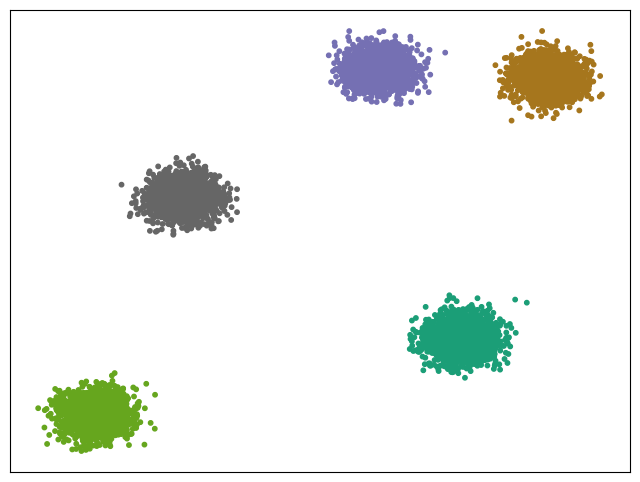

In [5]:
# S1
plt.figure(figsize=(8,6))
plt.scatter(s1[:, 0], s1[:, 1], c=true_labels_1, cmap='Dark2', s=10)
plt.xticks([])
plt.yticks([])
plt.show()

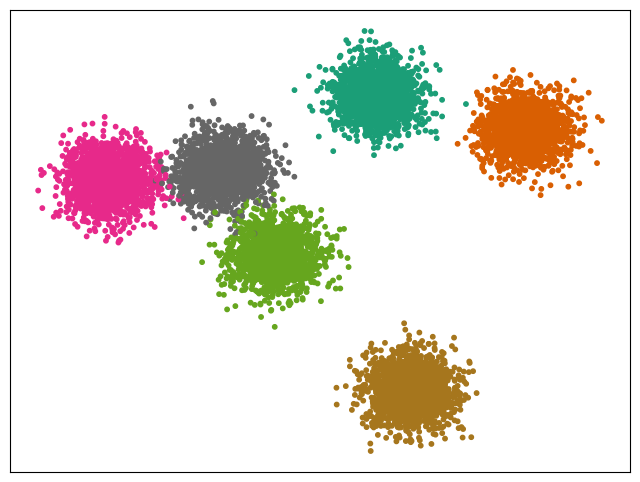

In [6]:
# S2
plt.figure(figsize=(8,6))
plt.scatter(s2[:, 0], s2[:, 1], c=true_labels_2, cmap='Dark2', s=10)
plt.xticks([])
plt.yticks([])
plt.show()

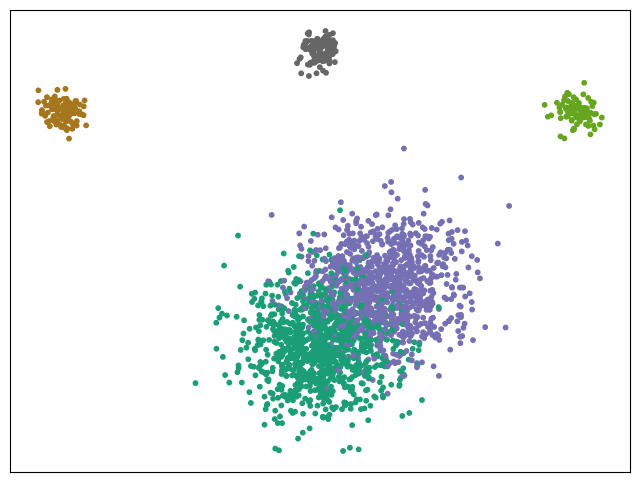

In [7]:
# S3
plt.figure(figsize=(8,6))
plt.scatter(s3[:, 0], s3[:, 1], c=y_3, cmap='Dark2', s=10)
plt.xticks([])
plt.yticks([])
plt.show()

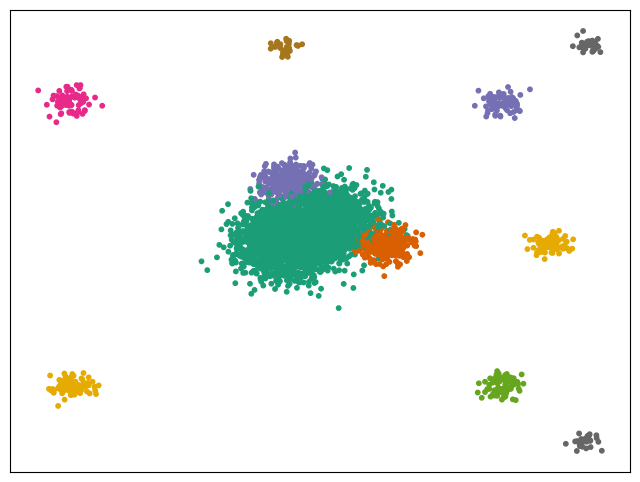

In [8]:
# S4
plt.figure(figsize=(8,6))
plt.scatter(s4[:, 0], s4[:, 1], c=y_4, s=10, cmap='Dark2')
plt.xticks([])
plt.yticks([])
plt.show()

### Real datasets

In [9]:
# Parkinsons
data_parkinson = fetch_openml(name='parkinsons', version=1, as_frame=True)
X_parkinson = data_parkinson.data
y_parkinson_raw = data_parkinson.target

le_parkinson = LabelEncoder()
y_parkinson = le_parkinson.fit_transform(y_parkinson_raw)
num_classes_parkinson = len(np.unique(y_parkinson))

X_park = StandardScaler().fit_transform(X_parkinson)
name_park = "Pks"
k_park = num_classes_parkinson

# Blood Transfusion
data_blood = fetch_openml(name='blood-transfusion-service-center', version=1, as_frame=True)
X_blood = data_blood.data
y_blood_raw = data_blood.target

le = LabelEncoder()
y_blood = le.fit_transform(y_blood_raw)
num_classes_blood = len(np.unique(y_blood))

X_blood_scaled = StandardScaler().fit_transform(X_blood)

X_blood = X_blood_scaled
name_blood = "Bld"
k_blood = num_classes_blood

# HTRU2
htru2 = fetch_ucirepo(id=372)
X_htru2 = htru2.data.features.to_numpy()
y_raw_htru2 = htru2.data.targets.iloc[:, 0]  # Single binary column

le_htru2 = LabelEncoder()
y_htru2 = le_htru2.fit_transform(y_raw_htru2)
num_classes_htru2 = len(np.unique(y_htru2))

X_htr= StandardScaler().fit_transform(X_htru2)
name_htr = "htr"
k_htr = num_classes_htru2

# Spambase
data_spambase = fetch_openml(name='spambase', version=1, as_frame=True)
X_spambase = data_spambase.data
y_spambase_raw = data_spambase.target

le_spam = LabelEncoder()
y_spambase = le_spam.fit_transform(y_spambase_raw)
num_classes_spambase = len(np.unique(y_spambase))

X_spam = StandardScaler().fit_transform(X_spambase)
name_spam = "Spm"
k_spam = num_classes_spambase

# Bank Marketing
data_bank = fetch_openml(name='bank-marketing', version=1, as_frame=True)
X_bank = data_bank.data.select_dtypes(include=[np.number])  # numeric features only
y_bank_raw = data_bank.target

le_bank = LabelEncoder()
y_bank = le_bank.fit_transform(y_bank_raw)
num_classes_bank = len(np.unique(y_bank))

X_bank = StandardScaler().fit_transform(X_bank)
name_bank = "Bnk"
k_bank = num_classes_bank

# Wine
data_wine = load_wine()
X_wine = data_wine.data
y_wine = data_wine.target

scaler = StandardScaler()

X_wine = scaler.fit_transform(X_wine)
name_wine = "Wne"
k_wine = len(set(y_wine))

# Digits
data_digits = load_digits()
X_digits = data_digits.data

pca = PCA(n_components=0.999)
X_digits = pca.fit_transform(X_digits)
name_digits = "Dgt"
k_digits = 10

# 20 Newsgroups
data_20ng = fetch_20newsgroups(subset='train')
num_classes_20ng = 20

vectorizer = TfidfVectorizer(stop_words='english')
X_tfidf = vectorizer.fit_transform(data_20ng.data)

svd = TruncatedSVD(n_components=50, random_state=0)
X_svd = svd.fit_transform(X_tfidf)

X_ng = X_svd
name_ng = "Nsg"
k_ng = num_classes_20ng

# STL-10
model = models.resnet18(weights='IMAGENET1K_V1')
model.fc = torch.nn.Identity()  # remove classification head
model.eval()

transform = transforms.Compose([
    transforms.Resize(96),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

dataset = STL10(root='data', split='train', download=True, transform=transform)

features, labels = [], []
with torch.no_grad():
    for img, label in dataset:
        f = model(img.unsqueeze(0)).squeeze().numpy()
        features.append(f)
        labels.append(label)

X_stl = np.array(features)
y_stl = np.array(labels)
num_classes_stl = len(np.unique(y_stl))

X_stl_scaled = StandardScaler().fit_transform(X_stl)

X_stl = X_stl_scaled
name_stl = "Stl"
k_stl = num_classes_stl

# BBC
bbc_ds = load_dataset("SetFit/bbc-news")
train_ds_bbc = bbc_ds["train"]
test_ds_bbc  = bbc_ds["test"]

texts_bbc = list(train_ds_bbc["text"]) + list(test_ds_bbc["text"])
labels_raw_bbc = list(train_ds_bbc["label"]) + list(test_ds_bbc["label"])
label_texts_bbc = list(train_ds_bbc["label_text"]) + list(test_ds_bbc["label_text"])

y_bbc = np.array(labels_raw_bbc, dtype=int)
k_bbc = len(np.unique(y_bbc))

label_map = {}
for lab, lab_txt in zip(labels_raw_bbc, label_texts_bbc):
    lab = int(lab)
    if lab not in label_map:
        label_map[lab] = lab_txt

model = SentenceTransformer("all-MiniLM-L6-v2")
X_embed_bbc = model.encode(
    texts_bbc,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
)

pca = PCA(n_components=50, random_state=0)
X_bbc_embed_50 = pca.fit_transform(X_embed_bbc)

X_bbc = X_bbc_embed_50
name_bbc = "Bbc"
k_bbc = len(np.unique(y_bbc))

# Minds-14
encoder_minilm = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

def build_minilm_pca_features(
    texts,
    n_components=50,
    encoder=encoder_minilm,
    random_state=0,
):
    """
    texts -> MiniLM embeddings -> PCA(n_components) -> L2-normalized
    """
    X_emb = encoder.encode(
        list(map(str, texts)),
        convert_to_numpy=True,
        show_progress_bar=True
    ).astype(np.float64)

    pca = PCA(
        n_components=n_components,
        whiten=False,
        random_state=random_state
    )
    X_pca = pca.fit_transform(X_emb)

    normalizer = Normalizer(norm="l2", copy=False)
    X_final = normalizer.fit_transform(X_pca)

    return X_final, pca, normalizer

ds_minds_train = load_dataset("DeepPavlov/minds14", split="train")
ds_minds_test  = load_dataset("DeepPavlov/minds14", split="test")

texts_minds = (
    list(map(str, ds_minds_train["utterance"])) +
    list(map(str, ds_minds_test["utterance"]))
)
labels_minds_raw = (
    list(ds_minds_train["label"]) +
    list(ds_minds_test["label"])
)

le_minds = LabelEncoder()
y_minds = le_minds.fit_transform(labels_minds_raw)
k_minds = len(np.unique(y_minds))

X_minds_minilm, pca_minds, norm_minds_emb = build_minilm_pca_features(
    texts_minds,
    n_components=85,
    encoder=encoder_minilm,
    random_state=0,
)

X_minds = X_minds_minilm
name_minds = "Mds"
k_minds = len(np.unique(y_minds))

# Banking 77
ds_train = load_dataset("PolyAI/banking77", split="train", revision="refs/convert/parquet")
ds_test  = load_dataset("PolyAI/banking77", split="test",  revision="refs/convert/parquet")

texts_b77 = list(map(str, ds_train["text"])) + list(map(str, ds_test["text"]))
labels_b77_raw = list(ds_train["label"]) + list(ds_test["label"])

le = LabelEncoder()
y_b77 = le.fit_transform(labels_b77_raw)

k_b77 = len(np.unique(y_b77))

encoder_b77 = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
X_b77_embed = encoder_b77.encode(
    texts_b77,
    convert_to_numpy=True,
    show_progress_bar=False
).astype(np.float64)

pca_b77 = PCA(
    n_components=50,
    whiten=False,
    random_state=0
)
X_b77_pca = pca_b77.fit_transform(X_b77_embed)

normalizer = Normalizer(norm="l2", copy=False)
X_b77 = normalizer.fit_transform(X_b77_pca)

pca_b77 = PCA(
    n_components=50,
    whiten=False,
    random_state=0
)

X_b77_pca = pca_b77.fit_transform(X_b77_embed)

normalizer = Normalizer(norm="l2", copy=False)

X_b77 = normalizer.fit_transform(X_b77_pca)
name_b77 = "B77"
k_b77 = len(np.unique(y_b77))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 321MB/s]
100%|██████████| 2.64G/2.64G [05:38<00:00, 7.80MB/s]


README.md:   0%|          | 0.00/880 [00:00<?, ?B/s]

train.jsonl: 0.00B [00:00, ?B/s]

test.jsonl: 0.00B [00:00, ?B/s]

...

0000.parquet:   0%|          | 0.00/93.9k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [10]:
real_datasets = {
    name_park: (X_park, k_park),
    name_blood: (X_blood, k_blood),
    name_htr: (X_htr, k_htr),
    name_spam: (X_spam, k_spam),
    name_bank: (X_bank, k_bank),
    name_wine: (X_wine, k_wine),
    name_digits: (X_digits, k_digits),
    name_ng: (X_ng, k_ng),
    name_stl: (X_stl, k_stl),
    name_bbc: (X_bbc, k_bbc),
    name_minds: (X_minds, k_minds),
    name_b77: (X_b77, k_b77)
}

print(list(real_datasets.keys()))

['Pks', 'Bld', 'htr', 'Spm', 'Bnk', 'Wne', 'Dgt', 'Nsg', 'Stl', 'Bbc', 'Mds', 'B77']


In [11]:
all_sets = {**synthetic_datasets, **real_datasets}
#print(list(all_sets.keys()))

## $k$ selection experiment: $S_{mM}$, subsample averages $S_m$, $S_M$, averages $S_m$, $S_M$, CH, DB

In [12]:
results_main = {}   # dataset_name -> dict of outputs

### S1

,avg S_micro,avg S_macro,w_micro,S_mM,std S_mM,se S_mM,LCB S_mM,B_eff,sample_size,sample_fraction
k,,,,,,,,,,
2,0.543974,0.564428,0.271146,0.560315,0.012104,0.003827,0.556488,10,6000,0.6
3,0.669707,0.728263,0.316496,0.713687,0.007261,0.002296,0.711390,10,6000,0.6
4,0.803408,0.841111,0.126798,0.836336,0.000300,0.000095,0.836241,10,6000,0.6
5,0.872739,0.872835,0.418225,0.872850,0.000799,0.000253,0.872597,10,6000,0.6
6,0.761958,0.690002,0.873881,0.752887,0.006988,0.002210,0.750677,10,6000,0.6
7,0.653186,0.561926,0.866085,0.640980,0.008437,0.002668,0.638313,10,6000,0.6
8,0.584334,0.488946,0.814066,0.567547,0.054886,0.017356,0.550191,10,6000,0.6
9,0.509273,0.427984,0.754455,0.491681,0.067308,0.021285,0.470396,10,6000,0.6
10,0.425097,0.375665,0.714479,0.414297,0.050645,0.016015,0.398282,10,6000,0.6


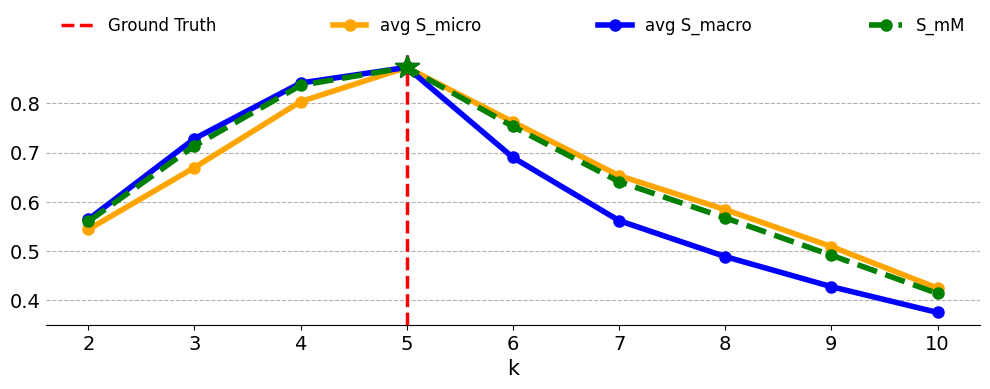


 K selected by S_mM: 5  | value at the ground-truth k:  0.8728502473873314

 K selected by subsample-average S_micro: 5  | value at the ground-truth k:  0.8727394607758383

 K selected by subsample-average S_macro: 5  |  value at the ground-truth k:  0.8728348966915238

 K selected by mean (full-run) S_micro: 5  | value at the ground-truth k:  0.8728351884814287

 K selected by mean (full-run) S_macro: 5  | value at the ground-truth k:  0.8728351884814287

 K selected by mean (full-run) CH: 5  | value at the ground-truth k:  284172.51209356484

 K selected by mean (full-run) DB: 5  | value at the ground-truth k:  0.17811588818080937


In [13]:
# Fit Composite Silhouette to S1
compsilhouette_s1 = CompSil(
    data=s1,
    k_values=range(2, 11),
    ground_truth=k_s1,
    num_samples=10,
    sample_size="auto",
    random_state=42)

# Evaluate for all candidate numbers of clusters
compsilhouette_s1.evaluate()

# get results dataframe
df_s1 = compsilhouette_s1.get_results_dataframe()
display(df_s1)

# Plot trends vs. k
compsilhouette_s1.plot_results()

# Store k selected by S_mM, subsample avg S_m, subsample avg S_M and
# each method's value at the ground-truth number of clusters
smm_k_s1, smm_val_s1 = argmax_k_and_value_at_gt(df_s1, "S_mM", k_s1)
subavg_micro_k_s1, subavg_micro_val_s1 = argmax_k_and_value_at_gt(df_s1, "avg S_micro", k_s1)
subavg_macro_k_s1, subavg_macro_val_s1 = argmax_k_and_value_at_gt(df_s1, "avg S_macro", k_s1)

# Store k selected by average S_m, average S_M, average CH, average DB and
# each method's value at the ground-truth number of clusters
full_out_s1 = mean_metrics_over_runs_choose_k(X=s1,
                                              num_runs=10,
                                              k_values=range(2, 11),
                                              random_state=42,
                                              kmeans_n_init=1,
                                              k_true=k_s1)

avg_micro_k_s1 = full_out_s1["k_micro"]
avg_micro_val_s1 = full_out_s1["mean_micro_at_k_micro"]

avg_macro_k_s1 = full_out_s1["k_macro"]
avg_macro_val_s1 = full_out_s1["mean_macro_at_k_macro"]

avg_ch_k_s1 = full_out_s1["k_ch"]
avg_ch_val_s1 = full_out_s1["mean_ch_at_k_ch"]

avg_db_k_s1 = full_out_s1["k_db"]
avg_db_val_s1 = full_out_s1["mean_db_at_k_db"]

# Print selected number of clusters (k) by each method and
# each method's value at the ground-truth number of clusters
print("\n K selected by S_mM:", smm_k_s1," | value at the ground-truth k: ",smm_val_s1)
print("\n K selected by subsample-average S_micro:", subavg_micro_k_s1," | value at the ground-truth k: ",subavg_micro_val_s1)
print("\n K selected by subsample-average S_macro:", subavg_macro_k_s1," |  value at the ground-truth k: ",subavg_macro_val_s1)

print("\n K selected by mean (full-run) S_micro:", avg_micro_k_s1, " | value at the ground-truth k: ", avg_micro_val_s1)
print("\n K selected by mean (full-run) S_macro:", avg_macro_k_s1, " | value at the ground-truth k: ", avg_macro_val_s1)
print("\n K selected by mean (full-run) CH:",      avg_ch_k_s1,    " | value at the ground-truth k: ", avg_ch_val_s1)
print("\n K selected by mean (full-run) DB:",      avg_db_k_s1,    " | value at the ground-truth k: ", avg_db_val_s1)

results_main[name_s1] = {
    "k_true": k_s1, # ground-truth k (number of clusters)

    "k_SmM": smm_k_s1, # k that corresponds to the highest composite silhouette S_mM value
    "SmM": smm_val_s1, # composite silhouette S_mM value at ground-truth k

    "k_subavg_micro": subavg_micro_k_s1, # k that corresponds to the highest subsample-average S_micro value
    "subavg_micro": subavg_micro_val_s1, # subsample-average S_micro value at ground-truth k

    "k_subavg_macro": subavg_macro_k_s1, # k that corresponds to the highest subsample-average S_macro value
    "subavg_macro": subavg_macro_val_s1, # subsample-average S_macro value at ground-truth k

    "k_avg_micro": avg_micro_k_s1, # k that corresponds to the highest mean (full-run) S_micro value
    "avg_micro": avg_micro_val_s1, # mean (full-run) S_micro value at ground-truth k

    "k_avg_macro": avg_macro_k_s1, # k that corresponds to the highest mean (full-run) S_macro value
    "avg_macro": avg_macro_val_s1, # mean (full-run) S_macro value at ground-truth k

    "k_avg_CH": avg_ch_k_s1, # k that corresponds to the highest mean CH value
    "avg_CH": avg_ch_val_s1, # mean CH value at ground-truth k

    "k_avg_DB": avg_db_k_s1,   # k that corresponds to the lowest mean DB value
    "avg_DB": avg_db_val_s1,   # mean DB value at ground-truth k
}

### S2

,avg S_micro,avg S_macro,w_micro,S_mM,std S_mM,se S_mM,LCB S_mM,B_eff,sample_size,sample_fraction
k,,,,,,,,,,
2,0.478568,0.551380,0.310326,0.540373,0.087527,0.027678,0.512695,10,6000,0.6
3,0.645981,0.695877,0.123128,0.689735,0.000916,0.000290,0.689446,10,6000,0.6
4,0.625265,0.669599,0.231999,0.660045,0.020250,0.006403,0.653642,10,6000,0.6
5,0.656689,0.691633,0.147078,0.686842,0.012201,0.003858,0.682984,10,6000,0.6
6,0.692379,0.692283,0.543542,0.692430,0.001629,0.000515,0.691915,10,6000,0.6
7,0.630838,0.588776,0.863544,0.625135,0.006591,0.002084,0.623051,10,6000,0.6
8,0.565683,0.509442,0.859681,0.557828,0.009321,0.002948,0.554880,10,6000,0.6
9,0.517499,0.457375,0.850255,0.508550,0.009011,0.002850,0.505701,10,6000,0.6
10,0.467464,0.414875,0.810255,0.457834,0.022666,0.007168,0.450666,10,6000,0.6


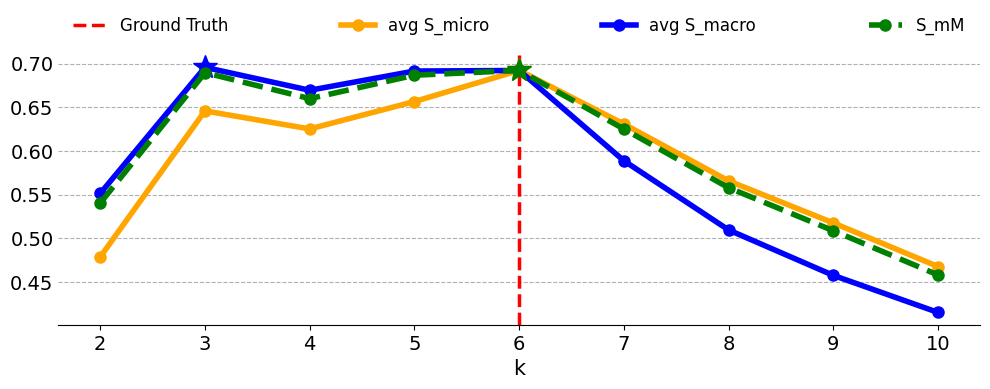


 K selected by S_mM: 6  | value at the ground-truth k:  0.6924303398086984

 K selected by subsample-average S_micro: 6  | value at the ground-truth k:  0.6923789558935086

 K selected by subsample-average S_macro: 3  | value at the ground-truth k:  0.6922827250452906

 K selected by mean (full-run) S_micro: 6  | value at the ground-truth k:  0.6923413012281355

 K selected by mean (full-run) S_macro: 3  | value at the ground-truth k:  0.6923949473710023

 K selected by mean (full-run) CH: 6  | value at the ground-truth k:  62274.87476141947

 K selected by mean (full-run) DB: 6  | value at the ground-truth k:  0.4291885605465855


In [14]:
# Fit Composite Silhouette to S2
compsilhouette_s2 = CompSil(
    data=s2,
    k_values=range(2, 11),
    ground_truth=k_s2,
    num_samples=10,
    sample_size="auto",
    random_state=42)

# Evaluate for all candidate numbers of clusters
compsilhouette_s2.evaluate()

# get results dataframe
df_s2 = compsilhouette_s2.get_results_dataframe()
display(df_s2)

# Plot trends vs. k
compsilhouette_s2.plot_results()

# Store k selected by S_mM, subsample avg S_m, subsample avg S_M and
# each method's value at the ground-truth number of clusters
smm_k_s2, smm_val_s2 = argmax_k_and_value_at_gt(df_s2, "S_mM", k_s2)
subavg_micro_k_s2, subavg_micro_val_s2 = argmax_k_and_value_at_gt(df_s2, "avg S_micro", k_s2)
subavg_macro_k_s2, subavg_macro_val_s2 = argmax_k_and_value_at_gt(df_s2, "avg S_macro", k_s2)

# Store k selected by average S_m, average S_M, average CH, average DB and
# each method's value at the ground-truth number of clusters
full_out_s2 = mean_metrics_over_runs_choose_k(X=s2, num_runs=10, k_values=range(2, 11), random_state=42, kmeans_n_init=1, k_true=k_s2)

avg_micro_k_s2 = full_out_s2["k_micro"]
avg_micro_val_s2 = full_out_s2["mean_micro_at_k_micro"]

avg_macro_k_s2 = full_out_s2["k_macro"]
avg_macro_val_s2 = full_out_s2["mean_macro_at_k_macro"]

avg_ch_k_s2 = full_out_s2["k_ch"]
avg_ch_val_s2 = full_out_s2["mean_ch_at_k_ch"]

avg_db_k_s2 = full_out_s2["k_db"]
avg_db_val_s2 = full_out_s2["mean_db_at_k_db"]

# Print selected number of clusters (k) by each method and
# each method's value at the ground-truth number of clusters
print("\n K selected by S_mM:", smm_k_s2," | value at the ground-truth k: ",smm_val_s2)
print("\n K selected by subsample-average S_micro:", subavg_micro_k_s2," | value at the ground-truth k: ",subavg_micro_val_s2)
print("\n K selected by subsample-average S_macro:", subavg_macro_k_s2," | value at the ground-truth k: ",subavg_macro_val_s2)

print("\n K selected by mean (full-run) S_micro:", avg_micro_k_s2, " | value at the ground-truth k: ", avg_micro_val_s2)
print("\n K selected by mean (full-run) S_macro:", avg_macro_k_s2, " | value at the ground-truth k: ", avg_macro_val_s2)
print("\n K selected by mean (full-run) CH:",      avg_ch_k_s2,    " | value at the ground-truth k: ", avg_ch_val_s2)
print("\n K selected by mean (full-run) DB:",      avg_db_k_s2,    " | value at the ground-truth k: ", avg_db_val_s2)

results_main[name_s2] = {
    "k_true": k_s2, # ground-truth k (number of clusters)

    "k_SmM": smm_k_s2, # k that corresponds to the highest composite silhouette S_mM value
    "SmM": smm_val_s2, # composite silhouette S_mM value at ground-truth k

    "k_subavg_micro": subavg_micro_k_s2, # k that corresponds to the highest subsample-average S_micro value
    "subavg_micro": subavg_micro_val_s2, # subsample-average S_micro value at ground-truth k

    "k_subavg_macro": subavg_macro_k_s2, # k that corresponds to the highest subsample-average S_macro value
    "subavg_macro": subavg_macro_val_s2, # subsample-average S_macro value at ground-truth k

    "k_avg_micro": avg_micro_k_s2, # k that corresponds to the highest mean (full-run) S_micro value
    "avg_micro": avg_micro_val_s2, # mean (full-run) S_micro value at ground-truth k

    "k_avg_macro": avg_macro_k_s2, # k that corresponds to the highest mean (full-run) S_macro value
    "avg_macro": avg_macro_val_s2, # mean (full-run) S_macro value at ground-truth k

    "k_avg_CH": avg_ch_k_s2, # k that corresponds to the highest mean CH value
    "avg_CH": avg_ch_val_s2, # mean CH value at ground-truth k

    "k_avg_DB": avg_db_k_s2,   # k that corresponds to the lowest mean DB value
    "avg_DB": avg_db_val_s2,   # mean DB value at ground-truth k
}

### S3

,avg S_micro,avg S_macro,w_micro,S_mM,std S_mM,se S_mM,LCB S_mM,B_eff,sample_size,sample_fraction
k,,,,,,,,,,
2,0.652485,0.553476,0.719590,0.632199,0.019736,0.001974,0.630225,100,1380,0.6
3,0.692784,0.722693,0.417507,0.710697,0.011653,0.001165,0.709532,100,1380,0.6
4,0.575947,0.713517,0.162411,0.691880,0.153564,0.015356,0.676524,100,1380,0.6
5,0.475706,0.706351,0.140070,0.675418,0.066985,0.006698,0.668720,100,1380,0.6
6,0.408575,0.629876,0.144928,0.598049,0.019725,0.001972,0.596076,100,1380,0.6
7,0.393760,0.581567,0.135373,0.556183,0.005838,0.000584,0.555600,100,1380,0.6
8,0.393794,0.544101,0.142162,0.522780,0.006304,0.000630,0.522150,100,1380,0.6
9,0.390761,0.514145,0.145178,0.496291,0.008405,0.000841,0.495450,100,1380,0.6
10,0.387941,0.491630,0.143931,0.476774,0.008252,0.000825,0.475949,100,1380,0.6


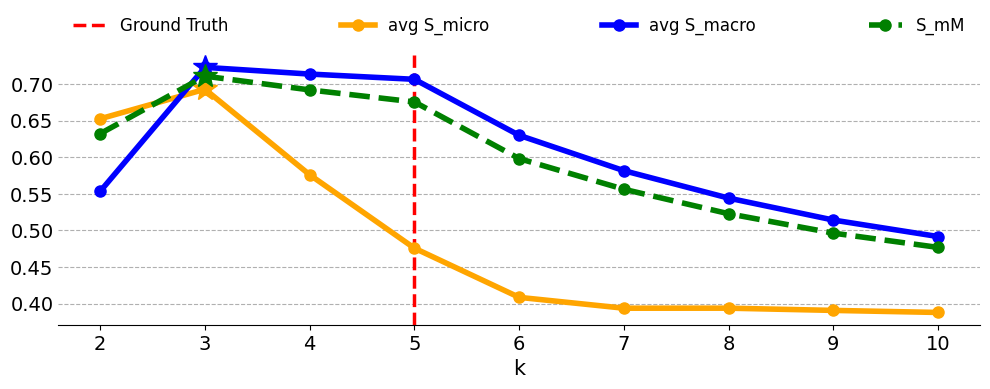


 K selected by S_mM: 3  | value at the ground-truth k:  0.6754184516479995

 K selected by subsample-average S_micro: 3  | value at the ground-truth k:  0.47570621411312203

 K selected by subsample-average S_macro: 3  | value at the ground-truth k:  0.7063509867304326

 K selected by mean (full-run) S_micro: 3  | value at the ground-truth k:  0.4851102785698272

 K selected by mean (full-run) S_macro: 5  | value at the ground-truth k:  0.7254020787248393

 K selected by mean (full-run) CH: 10  | value at the ground-truth k:  3869.8201924112486

 K selected by mean (full-run) DB: 5  | value at the ground-truth k:  0.4829297961242025


In [15]:
# Fit Composite Silhouette to S3
compsilhouette_s3 = CompSil(
    data=s3,
    k_values=range(2, 11),
    ground_truth=k_s3,
    num_samples=100,
    sample_size="auto",
    random_state=42)

# Evaluate for all candidate numbers of clusters
compsilhouette_s3.evaluate()

# get results dataframe
df_s3 = compsilhouette_s3.get_results_dataframe()
display(df_s3)

# Plot trends vs. k
compsilhouette_s3.plot_results()

smm_k_s3, smm_val_s3 = argmax_k_and_value_at_gt(df_s3, "S_mM", k_s3)
subavg_micro_k_s3, subavg_micro_val_s3 = argmax_k_and_value_at_gt(df_s3, "avg S_micro", k_s3)
subavg_macro_k_s3, subavg_macro_val_s3 = argmax_k_and_value_at_gt(df_s3, "avg S_macro", k_s3)

full_out_s3 = mean_metrics_over_runs_choose_k(X=s3, num_runs=10, k_values=range(2, 11), random_state=42, kmeans_n_init=1, k_true=k_s3)

avg_micro_k_s3 = full_out_s3["k_micro"]
avg_micro_val_s3 = full_out_s3["mean_micro_at_k_micro"]

avg_macro_k_s3 = full_out_s3["k_macro"]
avg_macro_val_s3 = full_out_s3["mean_macro_at_k_macro"]

avg_ch_k_s3 = full_out_s3["k_ch"]
avg_ch_val_s3 = full_out_s3["mean_ch_at_k_ch"]

avg_db_k_s3 = full_out_s3["k_db"]
avg_db_val_s3 = full_out_s3["mean_db_at_k_db"]

print("\n K selected by S_mM:", smm_k_s3," | value at the ground-truth k: ",smm_val_s3)
print("\n K selected by subsample-average S_micro:", subavg_micro_k_s3," | value at the ground-truth k: ",subavg_micro_val_s3)
print("\n K selected by subsample-average S_macro:", subavg_macro_k_s3," | value at the ground-truth k: ",subavg_macro_val_s3)

print("\n K selected by mean (full-run) S_micro:", avg_micro_k_s3, " | value at the ground-truth k: ", avg_micro_val_s3)
print("\n K selected by mean (full-run) S_macro:", avg_macro_k_s3, " | value at the ground-truth k: ", avg_macro_val_s3)
print("\n K selected by mean (full-run) CH:",      avg_ch_k_s3,    " | value at the ground-truth k: ", avg_ch_val_s3)
print("\n K selected by mean (full-run) DB:",      avg_db_k_s3,    " | value at the ground-truth k: ", avg_db_val_s3)

results_main[name_s3] = {
    "k_true": k_s3,

    "k_SmM": smm_k_s3,
    "SmM": smm_val_s3,

    "k_subavg_micro": subavg_micro_k_s3,
    "subavg_micro": subavg_micro_val_s3,

    "k_subavg_macro": subavg_macro_k_s3,
    "subavg_macro": subavg_macro_val_s3,

    "k_avg_micro": avg_micro_k_s3,
    "avg_micro": avg_micro_val_s3,

    "k_avg_macro": avg_macro_k_s3,
    "avg_macro": avg_macro_val_s3,

    "k_avg_CH": avg_ch_k_s3,
    "avg_CH": avg_ch_val_s3,

    "k_avg_DB": avg_db_k_s3,
    "avg_DB": avg_db_val_s3,
}

### S4

,avg S_micro,avg S_macro,w_micro,S_mM,std S_mM,se S_mM,LCB S_mM,B_eff,sample_size,sample_fraction
k,,,,,,,,,,
7,0.390741,0.633146,0.186463,0.591204,0.042742,0.009557,0.581647,20,2454,0.6
8,0.424667,0.657971,0.198297,0.613098,0.030372,0.006791,0.606306,20,2454,0.6
9,0.406151,0.669673,0.203360,0.617830,0.053167,0.011888,0.605942,20,2454,0.6
10,0.403107,0.662856,0.156004,0.623128,0.042268,0.009451,0.613677,20,2454,0.6
11,0.404801,0.664967,0.155464,0.624742,0.022425,0.005014,0.619728,20,2454,0.6
12,0.414685,0.654004,0.159130,0.616828,0.027663,0.006186,0.610643,20,2454,0.6
13,0.418903,0.653207,0.175382,0.612888,0.031735,0.007096,0.605791,20,2454,0.6
14,0.418032,0.643317,0.149929,0.609824,0.025459,0.005693,0.604131,20,2454,0.6
15,0.414147,0.638350,0.137843,0.607801,0.025961,0.005805,0.601996,20,2454,0.6


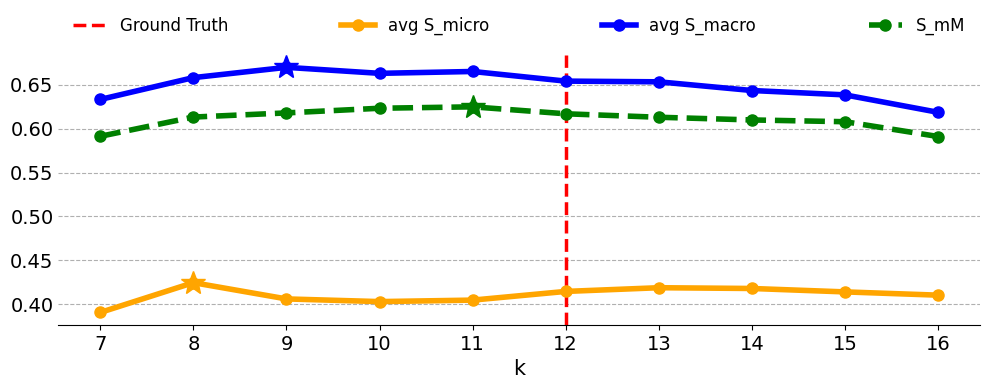


 K selected by S_mM: 11  | value at the ground-truth k:  0.6168282663498665

 K selected by subsample-average S_micro: 8  | value at the ground-truth k:  0.41468479604579656

 K selected by subsample-average S_macro: 9  | value at the ground-truth k:  0.6540036005676384

 K selected by mean (full-run) S_micro: 9  | value at the ground-truth k:  0.4121466113072601

 K selected by mean (full-run) S_macro: 9  | value at the ground-truth k:  0.6652336208788017

 K selected by mean (full-run) CH: 16  | value at the ground-truth k:  6888.196391290508

 K selected by mean (full-run) DB: 9  | value at the ground-truth k:  0.498312369681272


In [16]:
# Fit Composite Silhouette to S4
compsilhouette_s4 = CompSil(
    data=s4,
    k_values=range(7, 17),
    ground_truth=k_s4,
    num_samples=20,
    sample_size="auto",
    random_state=42)

# Evaluate for all candidate numbers of clusters
compsilhouette_s4.evaluate()

# get results dataframe
df_s4 = compsilhouette_s4.get_results_dataframe()
display(df_s4)

# Plot trends vs. k
compsilhouette_s4.plot_results()

smm_k_s4, smm_val_s4 = argmax_k_and_value_at_gt(df_s4, "S_mM", k_s4)
subavg_micro_k_s4, subavg_micro_val_s4 = argmax_k_and_value_at_gt(df_s4, "avg S_micro", k_s4)
subavg_macro_k_s4, subavg_macro_val_s4 = argmax_k_and_value_at_gt(df_s4, "avg S_macro", k_s4)

full_out_s4 = mean_metrics_over_runs_choose_k(X=s4, num_runs=20, k_values=range(7, 17), random_state=42, kmeans_n_init=1, k_true=k_s4)

avg_micro_k_s4 = full_out_s4["k_micro"]
avg_micro_val_s4 = full_out_s4["mean_micro_at_k_micro"]

avg_macro_k_s4 = full_out_s4["k_macro"]
avg_macro_val_s4 = full_out_s4["mean_macro_at_k_macro"]

avg_ch_k_s4 = full_out_s4["k_ch"]
avg_ch_val_s4 = full_out_s4["mean_ch_at_k_ch"]

avg_db_k_s4 = full_out_s4["k_db"]
avg_db_val_s4 = full_out_s4["mean_db_at_k_db"]

print("\n K selected by S_mM:", smm_k_s4," | value at the ground-truth k: ",smm_val_s4)
print("\n K selected by subsample-average S_micro:", subavg_micro_k_s4," | value at the ground-truth k: ",subavg_micro_val_s4)
print("\n K selected by subsample-average S_macro:", subavg_macro_k_s4," | value at the ground-truth k: ",subavg_macro_val_s4)

print("\n K selected by mean (full-run) S_micro:", avg_micro_k_s4, " | value at the ground-truth k: ", avg_micro_val_s4)
print("\n K selected by mean (full-run) S_macro:", avg_macro_k_s4, " | value at the ground-truth k: ", avg_macro_val_s4)
print("\n K selected by mean (full-run) CH:",      avg_ch_k_s4,    " | value at the ground-truth k: ", avg_ch_val_s4)
print("\n K selected by mean (full-run) DB:",      avg_db_k_s4,    " | value at the ground-truth k: ", avg_db_val_s4)

results_main[name_s4] = {
    "k_true": k_s4,

    "k_SmM": smm_k_s4,
    "SmM": smm_val_s4,

    "k_subavg_micro": subavg_micro_k_s4,
    "subavg_micro": subavg_micro_val_s4,

    "k_subavg_macro": subavg_macro_k_s4,
    "subavg_macro": subavg_macro_val_s4,

    "k_avg_micro": avg_micro_k_s4,
    "avg_micro": avg_micro_val_s4,

    "k_avg_macro": avg_macro_k_s4,
    "avg_macro": avg_macro_val_s4,

    "k_avg_CH": avg_ch_k_s4,
    "avg_CH": avg_ch_val_s4,

    "k_avg_DB": avg_db_k_s4,
    "avg_DB": avg_db_val_s4,
}

### Parkinsons

,avg S_micro,avg S_macro,w_micro,S_mM,std S_mM,se S_mM,LCB S_mM,B_eff,sample_size,sample_fraction
k,,,,,,,,,,
2,0.404031,0.308322,0.842305,0.389172,0.054734,0.009993,0.379179,30,195,1.0
3,0.274345,0.261705,0.733262,0.274117,0.012912,0.002357,0.271759,30,195,1.0
4,0.199483,0.214139,0.409351,0.210418,0.030664,0.005598,0.204820,30,195,1.0
5,0.191249,0.211447,0.349177,0.207112,0.023936,0.004370,0.202742,30,195,1.0
6,0.191244,0.206730,0.346269,0.205378,0.013707,0.002502,0.202876,30,195,1.0
7,0.200037,0.209230,0.419322,0.207355,0.012204,0.002228,0.205127,30,195,1.0


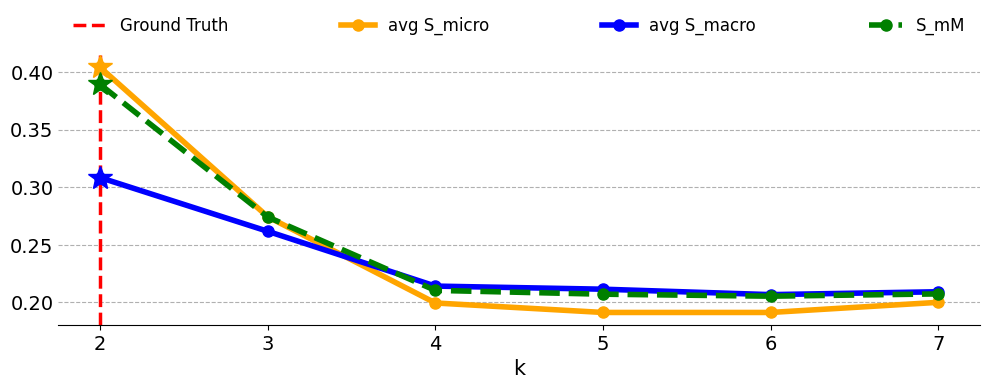


 K selected by S_mM: 2  | value at the ground-truth k:  0.3891720629214879

 K selected by subsample-average S_micro: 2  | value at the ground-truth k:  0.40403118562677703

 K selected by subsample-average S_macro: 2  | value at the ground-truth k:  0.30832206999311335

 K selected by mean (full-run) S_micro: 2  | value at the ground-truth k:  0.4125844195326206

 K selected by mean (full-run) S_macro: 2  | value at the ground-truth k:  0.31568531121368054

 K selected by mean (full-run) CH: 3  | value at the ground-truth k:  96.11827120284434

 K selected by mean (full-run) DB: 2  | value at the ground-truth k:  1.1239868370212938


In [17]:
# Fit Composite Silhouette to parkinsons
compsilhouette_park = CompSil(
    data=X_park,
    ground_truth=k_park,
    k_values=range(2, 8),
    num_samples=30,
    sample_size="auto",
    random_state=42
)

# Evaluate for all candidate numbers of clusters
compsilhouette_park.evaluate()

# get results dataframe
df_park = compsilhouette_park.get_results_dataframe()
display(df_park)

# Plot trends vs. k
compsilhouette_park.plot_results()

smm_k_park, smm_val_park = argmax_k_and_value_at_gt(df_park, "S_mM", k_park)
subavg_micro_k_park, subavg_micro_val_park = argmax_k_and_value_at_gt(df_park, "avg S_micro", k_park)
subavg_macro_k_park, subavg_macro_val_park = argmax_k_and_value_at_gt(df_park, "avg S_macro", k_park)

full_out_park = mean_metrics_over_runs_choose_k(X=X_park, num_runs=30, k_values=range(2, 8), random_state=42, kmeans_n_init=1, k_true=k_park)

avg_micro_k_park = full_out_park["k_micro"]
avg_micro_val_park = full_out_park["mean_micro_at_k_micro"]

avg_macro_k_park = full_out_park["k_macro"]
avg_macro_val_park = full_out_park["mean_macro_at_k_macro"]

avg_ch_k_park = full_out_park["k_ch"]
avg_ch_val_park = full_out_park["mean_ch_at_k_ch"]

avg_db_k_park = full_out_park["k_db"]
avg_db_val_park = full_out_park["mean_db_at_k_db"]

print("\n K selected by S_mM:", smm_k_park," | value at the ground-truth k: ",smm_val_park)
print("\n K selected by subsample-average S_micro:", subavg_micro_k_park," | value at the ground-truth k: ",subavg_micro_val_park)
print("\n K selected by subsample-average S_macro:", subavg_macro_k_park," | value at the ground-truth k: ",subavg_macro_val_park)

print("\n K selected by mean (full-run) S_micro:", avg_micro_k_park, " | value at the ground-truth k: ", avg_micro_val_park)
print("\n K selected by mean (full-run) S_macro:", avg_macro_k_park, " | value at the ground-truth k: ", avg_macro_val_park)
print("\n K selected by mean (full-run) CH:",      avg_ch_k_park,    " | value at the ground-truth k: ", avg_ch_val_park)
print("\n K selected by mean (full-run) DB:",      avg_db_k_park,    " | value at the ground-truth k: ", avg_db_val_park)

results_main[name_park] = {
    "k_true": k_park,

    "k_SmM": smm_k_park,
    "SmM": smm_val_park,

    "k_subavg_micro": subavg_micro_k_park,
    "subavg_micro": subavg_micro_val_park,

    "k_subavg_macro": subavg_macro_k_park,
    "subavg_macro": subavg_macro_val_park,

    "k_avg_micro": avg_micro_k_park,
    "avg_micro": avg_micro_val_park,

    "k_avg_macro": avg_macro_k_park,
    "avg_macro": avg_macro_val_park,

    "k_avg_CH": avg_ch_k_park,
    "avg_CH": avg_ch_val_park,

    "k_avg_DB": avg_db_k_park,
    "avg_DB": avg_db_val_park,
}

### Blood Transfusion

,avg S_micro,avg S_macro,w_micro,S_mM,std S_mM,se S_mM,LCB S_mM,B_eff,sample_size,sample_fraction
k,,,,,,,,,,
2,0.191575,0.275452,0.234510,0.261227,0.016971,0.002400,0.258827,50,598,0.799465
3,0.162166,0.191725,0.362139,0.183520,0.026887,0.003802,0.179718,50,598,0.799465
4,0.173008,0.220334,0.404982,0.208859,0.048878,0.006912,0.201946,50,598,0.799465
5,0.188799,0.258202,0.287296,0.243749,0.042493,0.006009,0.237739,50,598,0.799465
6,0.169283,0.249455,0.326188,0.228170,0.057172,0.008085,0.220084,50,598,0.799465
7,0.153862,0.250864,0.311199,0.225452,0.070477,0.009967,0.215485,50,598,0.799465


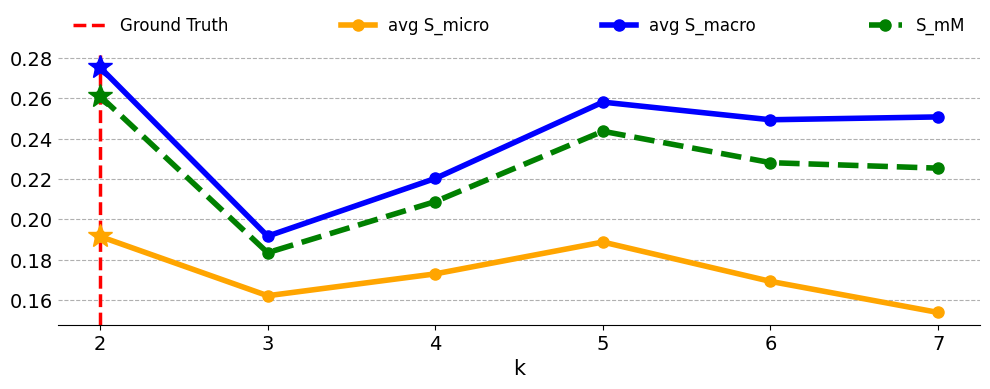


 K selected by S_mM: 2  | value at the ground-truth k:  0.26122729670370903

 K selected by subsample-average S_micro: 2  | value at the ground-truth k:  0.19157549400203508

 K selected by subsample-average S_macro: 2  | value at the ground-truth k:  0.275451595468865

 K selected by mean (full-run) S_micro: 5  | value at the ground-truth k:  0.16439301048333974

 K selected by mean (full-run) S_macro: 2  | value at the ground-truth k:  0.2705517132784533

 K selected by mean (full-run) CH: 5  | value at the ground-truth k:  155.75910088338003

 K selected by mean (full-run) DB: 2  | value at the ground-truth k:  1.3775139562749745


In [18]:
# Fit Composite Silhouette to Blood Transfusion
compsilhouette_blood = CompSil(
    data=X_blood,
    ground_truth=k_blood,
    k_values=range(2, 8),
    num_samples=50,
    sample_size="auto",
    random_state=42
)

# Evaluate for all candidate numbers of clusters
compsilhouette_blood.evaluate()

# get results dataframe
df_blood = compsilhouette_blood.get_results_dataframe()
display(df_blood)

# Plot trends vs. k
compsilhouette_blood.plot_results()

smm_k_blood, smm_val_blood = argmax_k_and_value_at_gt(df_blood, "S_mM", k_blood)
subavg_micro_k_blood, subavg_micro_val_blood = argmax_k_and_value_at_gt(df_blood, "avg S_micro", k_blood)
subavg_macro_k_blood, subavg_macro_val_blood = argmax_k_and_value_at_gt(df_blood, "avg S_macro", k_blood)

full_out_blood = mean_metrics_over_runs_choose_k(X=X_blood, num_runs=50, k_values=range(2, 8), random_state=42, kmeans_n_init=1, k_true=k_blood)

avg_micro_k_blood = full_out_blood["k_micro"]
avg_micro_val_blood = full_out_blood["mean_micro_at_k_micro"]

avg_macro_k_blood = full_out_blood["k_macro"]
avg_macro_val_blood = full_out_blood["mean_macro_at_k_macro"]

avg_ch_k_blood = full_out_blood["k_ch"]
avg_ch_val_blood = full_out_blood["mean_ch_at_k_ch"]

avg_db_k_blood = full_out_blood["k_db"]
avg_db_val_blood = full_out_blood["mean_db_at_k_db"]

print("\n K selected by S_mM:", smm_k_blood," | value at the ground-truth k: ",smm_val_blood)
print("\n K selected by subsample-average S_micro:", subavg_micro_k_blood," | value at the ground-truth k: ",subavg_micro_val_blood)
print("\n K selected by subsample-average S_macro:", subavg_macro_k_blood," | value at the ground-truth k: ",subavg_macro_val_blood)

print("\n K selected by mean (full-run) S_micro:", avg_micro_k_blood, " | value at the ground-truth k: ", avg_micro_val_blood)
print("\n K selected by mean (full-run) S_macro:", avg_macro_k_blood, " | value at the ground-truth k: ", avg_macro_val_blood)
print("\n K selected by mean (full-run) CH:",      avg_ch_k_blood,    " | value at the ground-truth k: ", avg_ch_val_blood)
print("\n K selected by mean (full-run) DB:",      avg_db_k_blood,    " | value at the ground-truth k: ", avg_db_val_blood)

results_main[name_blood] = {
    "k_true": k_blood,

    "k_SmM": smm_k_blood,
    "SmM": smm_val_blood,

    "k_subavg_micro": subavg_micro_k_blood,
    "subavg_micro": subavg_micro_val_blood,

    "k_subavg_macro": subavg_macro_k_blood,
    "subavg_macro": subavg_macro_val_blood,

    "k_avg_micro": avg_micro_k_blood,
    "avg_micro": avg_micro_val_blood,

    "k_avg_macro": avg_macro_k_blood,
    "avg_macro": avg_macro_val_blood,

    "k_avg_CH": avg_ch_k_blood,
    "avg_CH": avg_ch_val_blood,

    "k_avg_DB": avg_db_k_blood,
    "avg_DB": avg_db_val_blood,
}

### HTRU2

,avg S_micro,avg S_macro,w_micro,S_mM,std S_mM,se S_mM,LCB S_mM,B_eff,sample_size,sample_fraction
k,,,,,,,,,,
2,0.448854,0.278595,0.872617,0.427174,0.004256,0.000777,0.426397,30,10738,0.599955
3,0.365407,0.264482,0.858736,0.351182,0.007054,0.001288,0.349894,30,10738,0.599955
4,0.215116,0.187151,0.797713,0.209620,0.004090,0.000747,0.208873,30,10738,0.599955
5,0.175153,0.171543,0.533607,0.174792,0.026941,0.004919,0.169873,30,10738,0.599955
6,0.155532,0.171606,0.268367,0.169051,0.011698,0.002136,0.166916,30,10738,0.599955
7,0.125706,0.148869,0.240582,0.144417,0.016507,0.003014,0.141403,30,10738,0.599955


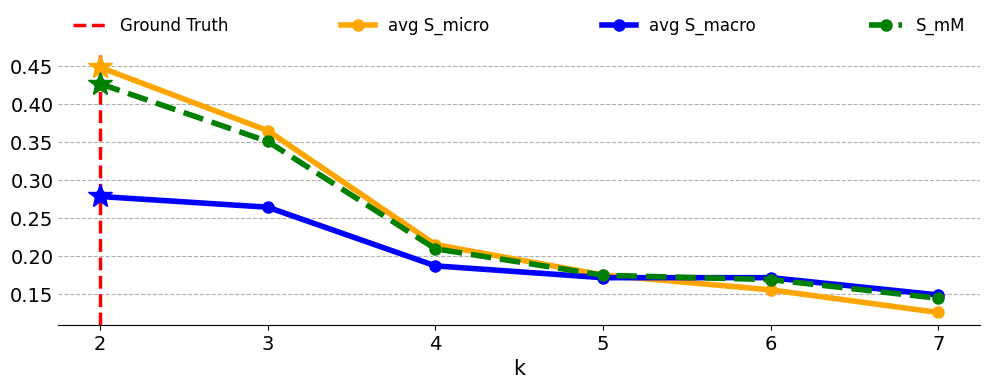


 K selected by S_mM: 2  | value at the ground-truth k:  0.42717449305289174

 K selected by subsample-average S_micro: 2  | value at the ground-truth k:  0.4488542096988372

 K selected by subsample-average S_macro: 2  | value at the ground-truth k:  0.2785950352453195

 K selected by mean (full-run) S_micro: 2  | value at the ground-truth k:  0.4500408638609316

 K selected by mean (full-run) S_macro: 2  | value at the ground-truth k:  0.2793448106404412

 K selected by mean (full-run) CH: 3  | value at the ground-truth k:  7378.472831638625

 K selected by mean (full-run) DB: 3  | value at the ground-truth k:  1.3495140050292633


In [19]:
# Fit Composite Silhouette to HTRU2
compsilhouette_htr = CompSil(
    data=X_htr,
    ground_truth=k_htr,
    k_values=range(2, 8),
    num_samples=30,
    sample_size="auto",
    random_state=42
)

# Evaluate for all candidate numbers of clusters
compsilhouette_htr.evaluate()

# get results dataframe
df_htr = compsilhouette_htr.get_results_dataframe()
display(df_htr)

# Plot trends vs. k
compsilhouette_htr.plot_results()

smm_k_htr, smm_val_htr = argmax_k_and_value_at_gt(df_htr, "S_mM", k_htr)
subavg_micro_k_htr, subavg_micro_val_htr = argmax_k_and_value_at_gt(df_htr, "avg S_micro", k_htr)
subavg_macro_k_htr, subavg_macro_val_htr = argmax_k_and_value_at_gt(df_htr, "avg S_macro", k_htr)

full_out_htr = mean_metrics_over_runs_choose_k(X=X_htr, num_runs=30, k_values=range(2, 8), random_state=42, kmeans_n_init=1, k_true=k_htr)

avg_micro_k_htr = full_out_htr["k_micro"]
avg_micro_val_htr = full_out_htr["mean_micro_at_k_micro"]

avg_macro_k_htr = full_out_htr["k_macro"]
avg_macro_val_htr = full_out_htr["mean_macro_at_k_macro"]

avg_ch_k_htr = full_out_htr["k_ch"]
avg_ch_val_htr = full_out_htr["mean_ch_at_k_ch"]

avg_db_k_htr = full_out_htr["k_db"]
avg_db_val_htr = full_out_htr["mean_db_at_k_db"]

print("\n K selected by S_mM:", smm_k_htr," | value at the ground-truth k: ",smm_val_htr)
print("\n K selected by subsample-average S_micro:", subavg_micro_k_htr," | value at the ground-truth k: ",subavg_micro_val_htr)
print("\n K selected by subsample-average S_macro:", subavg_macro_k_htr," | value at the ground-truth k: ",subavg_macro_val_htr)

print("\n K selected by mean (full-run) S_micro:", avg_micro_k_htr, " | value at the ground-truth k: ", avg_micro_val_htr)
print("\n K selected by mean (full-run) S_macro:", avg_macro_k_htr, " | value at the ground-truth k: ", avg_macro_val_htr)
print("\n K selected by mean (full-run) CH:",      avg_ch_k_htr,    " | value at the ground-truth k: ", avg_ch_val_htr)
print("\n K selected by mean (full-run) DB:",      avg_db_k_htr,    " | value at the ground-truth k: ", avg_db_val_htr)

results_main[name_htr] = {
    "k_true": k_htr,

    "k_SmM": smm_k_htr,
    "SmM": smm_val_htr,

    "k_subavg_micro": subavg_micro_k_htr,
    "subavg_micro": subavg_micro_val_htr,

    "k_subavg_macro": subavg_macro_k_htr,
    "subavg_macro": subavg_macro_val_htr,

    "k_avg_micro": avg_micro_k_htr,
    "avg_micro": avg_micro_val_htr,

    "k_avg_macro": avg_macro_k_htr,
    "avg_macro": avg_macro_val_htr,

    "k_avg_CH": avg_ch_k_htr,
    "avg_CH": avg_ch_val_htr,

    "k_avg_DB": avg_db_k_htr,
    "avg_DB": avg_db_val_htr,
}

### Spambase

,avg S_micro,avg S_macro,w_micro,S_mM,std S_mM,se S_mM,LCB S_mM,B_eff,sample_size,sample_fraction
k,,,,,,,,,,
2,0.134989,0.131229,0.507239,0.144744,0.167399,0.030563,0.114181,30,2760,0.59987
3,0.091606,0.131024,0.459315,0.135867,0.173035,0.031592,0.104275,30,2760,0.59987
4,0.019254,0.110686,0.384039,0.088766,0.103019,0.018809,0.069957,30,2760,0.59987
5,0.012805,0.103082,0.380873,0.077835,0.100307,0.018314,0.059522,30,2760,0.59987
6,-0.006912,0.103150,0.373550,0.070625,0.096041,0.017535,0.053091,30,2760,0.59987
7,-0.005606,0.102762,0.358906,0.074395,0.101389,0.018511,0.055884,30,2760,0.59987


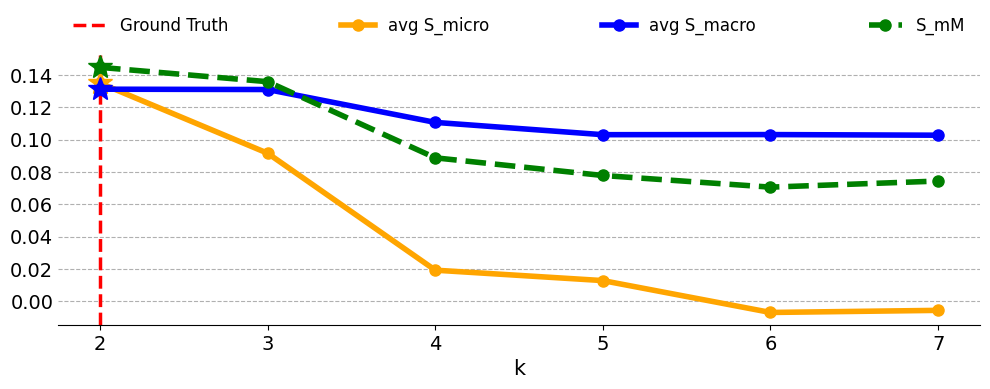


 K selected by S_mM: 2  | value at the ground-truth k:  0.1447436086200065

 K selected by subsample-average S_micro: 2  | value at the ground-truth k:  0.1349885960766043

 K selected by subsample-average S_macro: 2  | value at the ground-truth k:  0.1312290302825041

 K selected by mean (full-run) S_micro: 2  | value at the ground-truth k:  0.09480231696542224

 K selected by mean (full-run) S_macro: 2  | value at the ground-truth k:  0.10211248562522315

 K selected by mean (full-run) CH: 2  | value at the ground-truth k:  94.40461292658594

 K selected by mean (full-run) DB: 2  | value at the ground-truth k:  3.814758385286878


In [20]:
# Fit Composite Silhouette to Spambase
compsilhouette_spam = CompSil(
    data=X_spam,
    ground_truth=k_spam,
    k_values=range(2, 8),
    num_samples=30,
    sample_size="auto",
    random_state=42
)

# Evaluate for all candidate numbers of clusters
compsilhouette_spam.evaluate()

# get results dataframe
df_spam = compsilhouette_spam.get_results_dataframe()
display(df_spam)

# Plot trends vs. k
compsilhouette_spam.plot_results()

smm_k_spam, smm_val_spam = argmax_k_and_value_at_gt(df_spam, "S_mM", k_spam)
subavg_micro_k_spam, subavg_micro_val_spam = argmax_k_and_value_at_gt(df_spam, "avg S_micro", k_spam)
subavg_macro_k_spam, subavg_macro_val_spam = argmax_k_and_value_at_gt(df_spam, "avg S_macro", k_spam)

full_out_spam = mean_metrics_over_runs_choose_k(X=X_spam, num_runs=30, k_values=range(2, 8), random_state=42, kmeans_n_init=1, k_true=k_spam)

avg_micro_k_spam = full_out_spam["k_micro"]
avg_micro_val_spam = full_out_spam["mean_micro_at_k_micro"]

avg_macro_k_spam = full_out_spam["k_macro"]
avg_macro_val_spam = full_out_spam["mean_macro_at_k_macro"]

avg_ch_k_spam = full_out_spam["k_ch"]
avg_ch_val_spam = full_out_spam["mean_ch_at_k_ch"]

avg_db_k_spam = full_out_spam["k_db"]
avg_db_val_spam = full_out_spam["mean_db_at_k_db"]

print("\n K selected by S_mM:", smm_k_spam," | value at the ground-truth k: ",smm_val_spam)
print("\n K selected by subsample-average S_micro:", subavg_micro_k_spam," | value at the ground-truth k: ",subavg_micro_val_spam)
print("\n K selected by subsample-average S_macro:", subavg_macro_k_spam," | value at the ground-truth k: ",subavg_macro_val_spam)

print("\n K selected by mean (full-run) S_micro:", avg_micro_k_spam, " | value at the ground-truth k: ", avg_micro_val_spam)
print("\n K selected by mean (full-run) S_macro:", avg_macro_k_spam, " | value at the ground-truth k: ", avg_macro_val_spam)
print("\n K selected by mean (full-run) CH:",      avg_ch_k_spam,    " | value at the ground-truth k: ", avg_ch_val_spam)
print("\n K selected by mean (full-run) DB:",      avg_db_k_spam,    " | value at the ground-truth k: ", avg_db_val_spam)

results_main[name_spam] = {
    "k_true": k_spam,

    "k_SmM": smm_k_spam,
    "SmM": smm_val_spam,

    "k_subavg_micro": subavg_micro_k_spam,
    "subavg_micro": subavg_micro_val_spam,

    "k_subavg_macro": subavg_macro_k_spam,
    "subavg_macro": subavg_macro_val_spam,

    "k_avg_micro": avg_micro_k_spam,
    "avg_micro": avg_micro_val_spam,

    "k_avg_macro": avg_macro_k_spam,
    "avg_macro": avg_macro_val_spam,

    "k_avg_CH": avg_ch_k_spam,
    "avg_CH": avg_ch_val_spam,

    "k_avg_DB": avg_db_k_spam,
    "avg_DB": avg_db_val_spam,
}

### Bank Marketing

,avg S_micro,avg S_macro,w_micro,S_mM,std S_mM,se S_mM,LCB S_mM,B_eff,sample_size,sample_fraction
k,,,,,,,,,,
2,0.311070,0.231476,0.788223,0.294967,0.009481,0.001731,0.293236,30,18084,0.399991
3,0.241944,0.120268,0.781124,0.218754,0.056235,0.010267,0.208487,30,18084,0.399991
4,0.178930,0.055554,0.763362,0.152137,0.048554,0.008865,0.143273,30,18084,0.399991
5,0.131352,0.029631,0.752325,0.109452,0.045249,0.008261,0.101191,30,18084,0.399991
6,0.084765,0.000335,0.735509,0.064650,0.046651,0.008517,0.056132,30,18084,0.399991
7,0.045970,-0.021081,0.697011,0.027894,0.038198,0.006974,0.020920,30,18084,0.399991
8,0.036724,-0.023295,0.670555,0.019019,0.037886,0.006917,0.012102,30,18084,0.399991
9,0.025325,-0.026565,0.640371,0.010324,0.034540,0.006306,0.004018,30,18084,0.399991


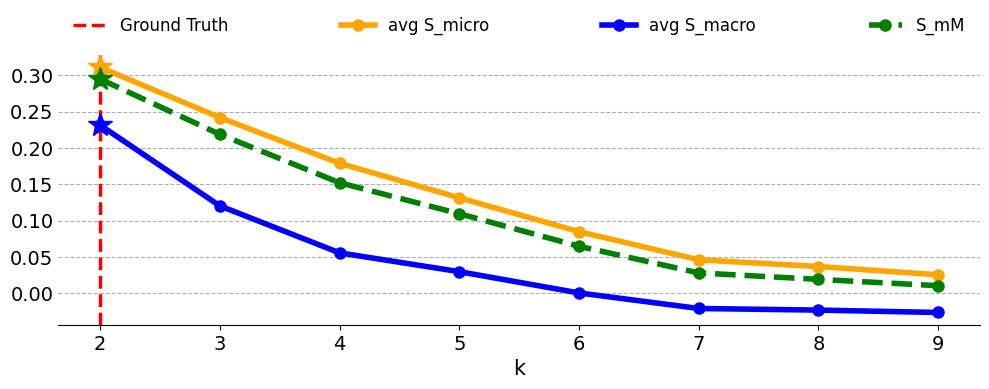


 K selected by S_mM: 2  | value at the ground-truth k:  0.2949669509451144

 K selected by subsample-average S_micro: 2  | value at the ground-truth k:  0.3110695481960102

 K selected by subsample-average S_macro: 2  | value at the ground-truth k:  0.231476463646701

 K selected by mean (full-run) S_micro: 2  | value at the ground-truth k:  0.35653367952165027

 K selected by mean (full-run) S_macro: 2  | value at the ground-truth k:  0.24813470134906845

 K selected by mean (full-run) CH: 2  | value at the ground-truth k:  7565.292079385109

 K selected by mean (full-run) DB: 2  | value at the ground-truth k:  1.5916546802460607


In [21]:
# Fit Composite Silhouette to Bank Marketing
compsilhouette_bank = CompSil(
    data=X_bank,
    ground_truth=k_bank,
    k_values=range(2, 10),
    num_samples=30,
    sample_size="auto",
    random_state=42
)

compsilhouette_bank.evaluate()

df_bank = compsilhouette_bank.get_results_dataframe()
display(df_bank)

compsilhouette_bank.plot_results()

smm_k_bank, smm_val_bank = argmax_k_and_value_at_gt(df_bank, "S_mM", k_bank)
subavg_micro_k_bank, subavg_micro_val_bank = argmax_k_and_value_at_gt(df_bank, "avg S_micro", k_bank)
subavg_macro_k_bank, subavg_macro_val_bank = argmax_k_and_value_at_gt(df_bank, "avg S_macro", k_bank)

full_out_bank = mean_metrics_over_runs_choose_k(X=X_bank, num_runs=30, k_values=range(2, 10), random_state=42, kmeans_n_init=1, k_true=k_bank)

avg_micro_k_bank = full_out_bank["k_micro"]
avg_micro_val_bank = full_out_bank["mean_micro_at_k_micro"]

avg_macro_k_bank = full_out_bank["k_macro"]
avg_macro_val_bank = full_out_bank["mean_macro_at_k_macro"]

avg_ch_k_bank = full_out_bank["k_ch"]
avg_ch_val_bank = full_out_bank["mean_ch_at_k_ch"]

avg_db_k_bank = full_out_bank["k_db"]
avg_db_val_bank = full_out_bank["mean_db_at_k_db"]

print("\n K selected by S_mM:", smm_k_bank," | value at the ground-truth k: ",smm_val_bank)
print("\n K selected by subsample-average S_micro:", subavg_micro_k_bank," | value at the ground-truth k: ",subavg_micro_val_bank)
print("\n K selected by subsample-average S_macro:", subavg_macro_k_bank," | value at the ground-truth k: ",subavg_macro_val_bank)

print("\n K selected by mean (full-run) S_micro:", avg_micro_k_bank, " | value at the ground-truth k: ", avg_micro_val_bank)
print("\n K selected by mean (full-run) S_macro:", avg_macro_k_bank, " | value at the ground-truth k: ", avg_macro_val_bank)
print("\n K selected by mean (full-run) CH:",      avg_ch_k_bank,    " | value at the ground-truth k: ", avg_ch_val_bank)
print("\n K selected by mean (full-run) DB:",      avg_db_k_bank,    " | value at the ground-truth k: ", avg_db_val_bank)

results_main[name_bank] = {
    "k_true": k_bank,

    "k_SmM": smm_k_bank,
    "SmM": smm_val_bank,

    "k_subavg_micro": subavg_micro_k_bank,
    "subavg_micro": subavg_micro_val_bank,

    "k_subavg_macro": subavg_macro_k_bank,
    "subavg_macro": subavg_macro_val_bank,

    "k_avg_micro": avg_micro_k_bank,
    "avg_micro": avg_micro_val_bank,

    "k_avg_macro": avg_macro_k_bank,
    "avg_macro": avg_macro_val_bank,

    "k_avg_CH": avg_ch_k_bank,
    "avg_CH": avg_ch_val_bank,

    "k_avg_DB": avg_db_k_bank,
    "avg_DB": avg_db_val_bank,
}

### Wine

,avg S_micro,avg S_macro,w_micro,S_mM,std S_mM,se S_mM,LCB S_mM,B_eff,sample_size,sample_fraction
k,,,,,,,,,,
2,0.261184,0.274715,0.318834,0.272448,0.022707,0.002271,0.270177,100,178,1.0
3,0.280953,0.286571,0.304763,0.284902,0.006146,0.000615,0.284287,100,178,1.0
4,0.237792,0.208490,0.735534,0.231097,0.024388,0.002439,0.228658,100,178,1.0
5,0.197611,0.163634,0.712574,0.189286,0.030596,0.003060,0.186227,100,178,1.0
6,0.170289,0.145093,0.650965,0.164440,0.034256,0.003426,0.161015,100,178,1.0
7,0.149704,0.133226,0.605115,0.146158,0.028150,0.002815,0.143343,100,178,1.0
8,0.137874,0.130877,0.557298,0.137581,0.022774,0.002277,0.135304,100,178,1.0
9,0.132535,0.134147,0.487372,0.136405,0.020322,0.002032,0.134372,100,178,1.0
10,0.129641,0.135080,0.454895,0.135372,0.018094,0.001809,0.133563,100,178,1.0


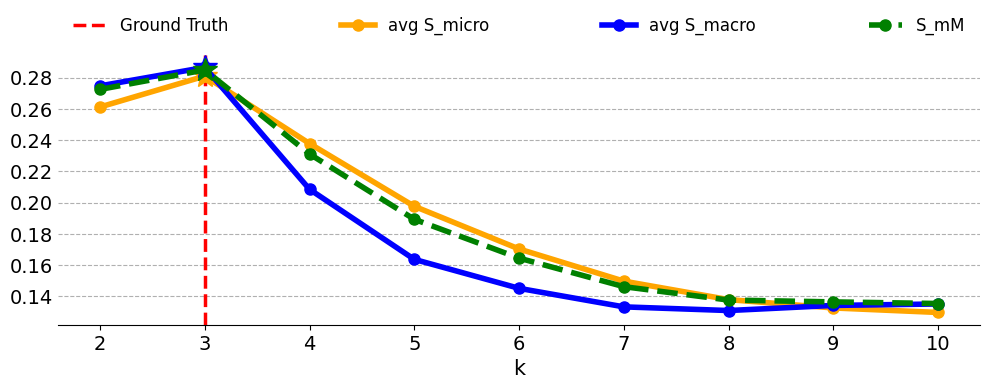


 K selected by S_mM: 3  | value at the ground-truth k:  0.28490201087504174

 K selected by subsample-average S_micro: 3  | value at the ground-truth k:  0.2809525439222744

 K selected by subsample-average S_macro: 3  | value at the ground-truth k:  0.2865707387936285

 K selected by mean (full-run) S_micro: 3  | value at the ground-truth k:  0.27959109335490195

 K selected by mean (full-run) S_macro: 3  | value at the ground-truth k:  0.2853312879829982

 K selected by mean (full-run) CH: 3  | value at the ground-truth k:  69.67840346183465

 K selected by mean (full-run) DB: 3  | value at the ground-truth k:  1.4066000869438846


In [22]:
compsilhouette_wine = CompSil(
    data=X_wine,
    ground_truth=k_wine,
    k_values=range(2, 11),
    num_samples=100,
    sample_size="auto",
    random_state=42
)

compsilhouette_wine.evaluate()

df_wine = compsilhouette_wine.get_results_dataframe()
display(df_wine)

compsilhouette_wine.plot_results()

smm_k_wine, smm_val_wine = argmax_k_and_value_at_gt(df_wine, "S_mM", k_wine)
subavg_micro_k_wine, subavg_micro_val_wine = argmax_k_and_value_at_gt(df_wine, "avg S_micro", k_wine)
subavg_macro_k_wine, subavg_macro_val_wine = argmax_k_and_value_at_gt(df_wine, "avg S_macro", k_wine)

full_out_wine = mean_metrics_over_runs_choose_k(X=X_wine, num_runs=10, k_values=range(2, 11), random_state=42, kmeans_n_init=1, k_true=k_wine)

avg_micro_k_wine = full_out_wine["k_micro"]
avg_micro_val_wine = full_out_wine["mean_micro_at_k_micro"]

avg_macro_k_wine = full_out_wine["k_macro"]
avg_macro_val_wine = full_out_wine["mean_macro_at_k_macro"]

avg_ch_k_wine = full_out_wine["k_ch"]
avg_ch_val_wine = full_out_wine["mean_ch_at_k_ch"]

avg_db_k_wine = full_out_wine["k_db"]
avg_db_val_wine = full_out_wine["mean_db_at_k_db"]

print("\n K selected by S_mM:", smm_k_wine," | value at the ground-truth k: ",smm_val_wine)
print("\n K selected by subsample-average S_micro:", subavg_micro_k_wine," | value at the ground-truth k: ",subavg_micro_val_wine)
print("\n K selected by subsample-average S_macro:", subavg_macro_k_wine," | value at the ground-truth k: ",subavg_macro_val_wine)

print("\n K selected by mean (full-run) S_micro:", avg_micro_k_wine, " | value at the ground-truth k: ", avg_micro_val_wine)
print("\n K selected by mean (full-run) S_macro:", avg_macro_k_wine, " | value at the ground-truth k: ", avg_macro_val_wine)
print("\n K selected by mean (full-run) CH:",      avg_ch_k_wine,    " | value at the ground-truth k: ", avg_ch_val_wine)
print("\n K selected by mean (full-run) DB:",      avg_db_k_wine,    " | value at the ground-truth k: ", avg_db_val_wine)

results_main[name_wine] = {
    "k_true": k_wine,

    "k_SmM": smm_k_wine,
    "SmM": smm_val_wine,

    "k_subavg_micro": subavg_micro_k_wine,
    "subavg_micro": subavg_micro_val_wine,

    "k_subavg_macro": subavg_macro_k_wine,
    "subavg_macro": subavg_macro_val_wine,

    "k_avg_micro": avg_micro_k_wine,
    "avg_micro": avg_micro_val_wine,

    "k_avg_macro": avg_macro_k_wine,
    "avg_macro": avg_macro_val_wine,

    "k_avg_CH": avg_ch_k_wine,
    "avg_CH": avg_ch_val_wine,

    "k_avg_DB": avg_db_k_wine,
    "avg_DB": avg_db_val_wine,
}

### Digits

,avg S_micro,avg S_macro,w_micro,S_mM,std S_mM,se S_mM,LCB S_mM,B_eff,sample_size,sample_fraction
k,,,,,,,,,,
2,0.056998,0.053567,0.662569,0.056376,0.020471,0.006473,0.049903,10,1437,0.799666
3,0.093089,0.100495,0.354233,0.099008,0.013558,0.004287,0.094720,10,1437,0.799666
4,0.106848,0.119370,0.417235,0.116444,0.013808,0.004366,0.112078,10,1437,0.799666
5,0.122693,0.142071,0.316714,0.138267,0.014323,0.004529,0.133738,10,1437,0.799666
6,0.133041,0.166312,0.239480,0.159352,0.012085,0.003822,0.155530,10,1437,0.799666
7,0.146606,0.169680,0.202664,0.165684,0.013788,0.004360,0.161324,10,1437,0.799666
8,0.156839,0.172848,0.256113,0.169359,0.015037,0.004755,0.164604,10,1437,0.799666
9,0.166584,0.176458,0.241383,0.174422,0.019024,0.006016,0.168406,10,1437,0.799666
10,0.174844,0.181559,0.305720,0.179875,0.008177,0.002586,0.177289,10,1437,0.799666


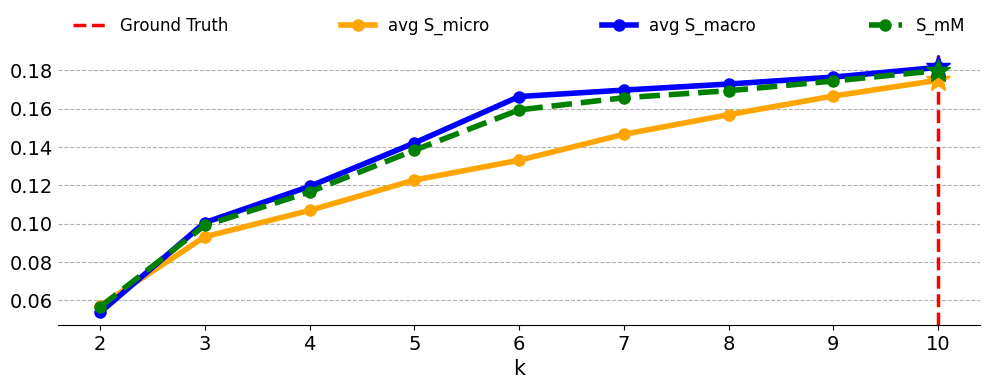


 K selected by S_mM: 10  | value at the ground-truth k:  0.1798746930286842

 K selected by subsample-average S_micro: 10  | value at the ground-truth k:  0.17484394725927066

 K selected by subsample-average S_macro: 10  | value at the ground-truth k:  0.18155885860796214

 K selected by mean (full-run) S_micro: 10  | value at the ground-truth k:  0.1716860735193883

 K selected by mean (full-run) S_macro: 9  | value at the ground-truth k:  0.17724918759785063

 K selected by mean (full-run) CH: 6  | value at the ground-truth k:  159.9940948313147

 K selected by mean (full-run) DB: 10  | value at the ground-truth k:  2.0142594189689413


In [23]:
compsilhouette_digits = CompSil(
    data=X_digits,
    ground_truth=k_digits,
    k_values=range(2, 11),
    num_samples=10,
    sample_size="auto",
    random_state=10
)

compsilhouette_digits.evaluate()

df_digits = compsilhouette_digits.get_results_dataframe()
display(df_digits)

compsilhouette_digits.plot_results()

smm_k_digits, smm_val_digits = argmax_k_and_value_at_gt(df_digits, "S_mM", k_digits)
subavg_micro_k_digits, subavg_micro_val_digits = argmax_k_and_value_at_gt(df_digits, "avg S_micro", k_digits)
subavg_macro_k_digits, subavg_macro_val_digits = argmax_k_and_value_at_gt(df_digits, "avg S_macro", k_digits)

full_out_digits = mean_metrics_over_runs_choose_k(X=X_digits, num_runs=10, k_values=range(2, 11), random_state=42, kmeans_n_init=1, k_true=k_digits)

avg_micro_k_digits = full_out_digits["k_micro"]
avg_micro_val_digits = full_out_digits["mean_micro_at_k_micro"]

avg_macro_k_digits = full_out_digits["k_macro"]
avg_macro_val_digits = full_out_digits["mean_macro_at_k_macro"]

avg_ch_k_digits = full_out_digits["k_ch"]
avg_ch_val_digits = full_out_digits["mean_ch_at_k_ch"]

avg_db_k_digits = full_out_digits["k_db"]
avg_db_val_digits = full_out_digits["mean_db_at_k_db"]

print("\n K selected by S_mM:", smm_k_digits," | value at the ground-truth k: ",smm_val_digits)
print("\n K selected by subsample-average S_micro:", subavg_micro_k_digits," | value at the ground-truth k: ",subavg_micro_val_digits)
print("\n K selected by subsample-average S_macro:", subavg_macro_k_digits," | value at the ground-truth k: ",subavg_macro_val_digits)

print("\n K selected by mean (full-run) S_micro:", avg_micro_k_digits, " | value at the ground-truth k: ", avg_micro_val_digits)
print("\n K selected by mean (full-run) S_macro:", avg_macro_k_digits, " | value at the ground-truth k: ", avg_macro_val_digits)
print("\n K selected by mean (full-run) CH:",      avg_ch_k_digits,    " | value at the ground-truth k: ", avg_ch_val_digits)
print("\n K selected by mean (full-run) DB:",      avg_db_k_digits,    " | value at the ground-truth k: ", avg_db_val_digits)

results_main[name_digits] = {
    "k_true": k_digits,

    "k_SmM": smm_k_digits,
    "SmM": smm_val_digits,

    "k_subavg_micro": subavg_micro_k_digits,
    "subavg_micro": subavg_micro_val_digits,

    "k_subavg_macro": subavg_macro_k_digits,
    "subavg_macro": subavg_macro_val_digits,

    "k_avg_micro": avg_micro_k_digits,
    "avg_micro": avg_micro_val_digits,

    "k_avg_macro": avg_macro_k_digits,
    "avg_macro": avg_macro_val_digits,

    "k_avg_CH": avg_ch_k_digits,
    "avg_CH": avg_ch_val_digits,

    "k_avg_DB": avg_db_k_digits,
    "avg_DB": avg_db_val_digits,
}

### 20 Newsgroups

,avg S_micro,avg S_macro,w_micro,S_mM,std S_mM,se S_mM,LCB S_mM,B_eff,sample_size,sample_fraction
k,,,,,,,,,,
15,-0.015873,0.083159,0.240556,0.061165,0.032896,0.007356,0.053809,20,6788,0.599965
16,-0.014108,0.090076,0.235944,0.067248,0.033254,0.007436,0.059812,20,6788,0.599965
17,-0.017969,0.085698,0.217768,0.064873,0.033249,0.007435,0.057439,20,6788,0.599965
18,-0.016590,0.094426,0.190077,0.074500,0.032496,0.007266,0.067234,20,6788,0.599965
19,-0.022182,0.093855,0.170846,0.074838,0.027218,0.006086,0.068752,20,6788,0.599965
20,-0.016437,0.102316,0.192145,0.080360,0.023821,0.005326,0.075033,20,6788,0.599965
21,-0.006667,0.114383,0.203752,0.091129,0.035877,0.008022,0.083107,20,6788,0.599965
22,-0.003628,0.118437,0.211901,0.093957,0.039998,0.008944,0.085013,20,6788,0.599965
23,-0.004472,0.120610,0.201068,0.096437,0.038875,0.008693,0.087744,20,6788,0.599965


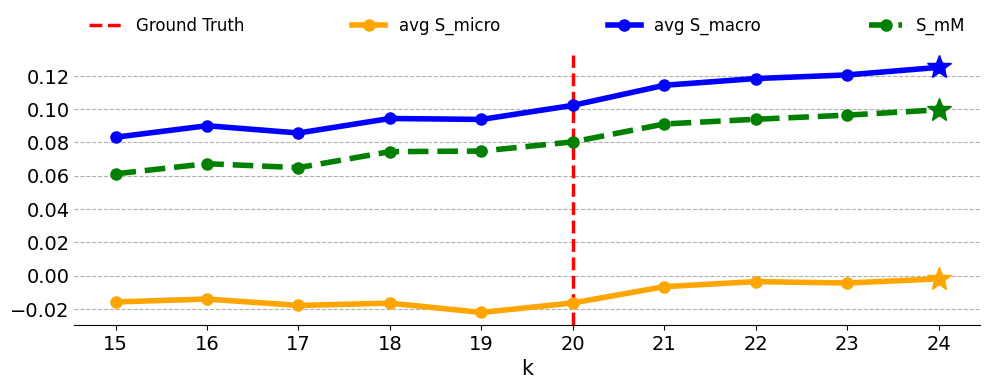

/usr/local/lib/python3.12/dist-packages/sklearn/mixture/_base.py:269: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/mixture/_base.py:269: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(



 K selected by S_mM: 24  | value at the ground-truth k:  0.08035988310204256

 K selected by subsample-average S_micro: 24  | value at the ground-truth k:  -0.016437241429056955

 K selected by subsample-average S_macro: 24  | value at the ground-truth k:  0.10231578914233441

 K selected by mean (full-run) S_micro: 24  | value at the ground-truth k:  -0.034139607459376164

 K selected by mean (full-run) S_macro: 24  | value at the ground-truth k:  0.015657819117951673

 K selected by mean (full-run) CH: 24  | value at the ground-truth k:  185.49012538627025

 K selected by mean (full-run) DB: 24  | value at the ground-truth k:  3.089601231494301


In [24]:
compsilhouette_ng = CompSil(
    data=X_ng,
    ground_truth=k_ng,
    k_values=range(15, 25),
    num_samples=20,
    sample_size="auto",
    random_state=42
)

compsilhouette_ng.evaluate()

df_ng = compsilhouette_ng.get_results_dataframe()
display(df_ng)

compsilhouette_ng.plot_results()

smm_k_ng, smm_val_ng = argmax_k_and_value_at_gt(df_ng, "S_mM", k_ng)
subavg_micro_k_ng, subavg_micro_val_ng = argmax_k_and_value_at_gt(df_ng, "avg S_micro", k_ng)
subavg_macro_k_ng, subavg_macro_val_ng = argmax_k_and_value_at_gt(df_ng, "avg S_macro", k_ng)

full_out_ng = mean_metrics_over_runs_choose_k(X=X_ng, num_runs=20, k_values=range(15, 25), random_state=42, kmeans_n_init=1, k_true=k_ng)

avg_micro_k_ng = full_out_ng["k_micro"]
avg_micro_val_ng = full_out_ng["mean_micro_at_k_micro"]

avg_macro_k_ng = full_out_ng["k_macro"]
avg_macro_val_ng = full_out_ng["mean_macro_at_k_macro"]

avg_ch_k_ng = full_out_ng["k_ch"]
avg_ch_val_ng = full_out_ng["mean_ch_at_k_ch"]

avg_db_k_ng = full_out_ng["k_db"]
avg_db_val_ng = full_out_ng["mean_db_at_k_db"]

print("\n K selected by S_mM:", smm_k_ng," | value at the ground-truth k: ",smm_val_ng)
print("\n K selected by subsample-average S_micro:", subavg_micro_k_ng," | value at the ground-truth k: ",subavg_micro_val_ng)
print("\n K selected by subsample-average S_macro:", subavg_macro_k_ng," | value at the ground-truth k: ",subavg_macro_val_ng)

print("\n K selected by mean (full-run) S_micro:", avg_micro_k_ng, " | value at the ground-truth k: ", avg_micro_val_ng)
print("\n K selected by mean (full-run) S_macro:", avg_macro_k_ng, " | value at the ground-truth k: ", avg_macro_val_ng)
print("\n K selected by mean (full-run) CH:",      avg_ch_k_ng,    " | value at the ground-truth k: ", avg_ch_val_ng)
print("\n K selected by mean (full-run) DB:",      avg_db_k_ng,    " | value at the ground-truth k: ", avg_db_val_ng)

results_main[name_ng] = {
    "k_true": k_ng,

    "k_SmM": smm_k_ng,
    "SmM": smm_val_ng,

    "k_subavg_micro": subavg_micro_k_ng,
    "subavg_micro": subavg_micro_val_ng,

    "k_subavg_macro": subavg_macro_k_ng,
    "subavg_macro": subavg_macro_val_ng,

    "k_avg_micro": avg_micro_k_ng,
    "avg_micro": avg_micro_val_ng,

    "k_avg_macro": avg_macro_k_ng,
    "avg_macro": avg_macro_val_ng,

    "k_avg_CH": avg_ch_k_ng,
    "avg_CH": avg_ch_val_ng,

    "k_avg_DB": avg_db_k_ng,
    "avg_DB": avg_db_val_ng,
}

### STL-10

,avg S_micro,avg S_macro,w_micro,S_mM,std S_mM,se S_mM,LCB S_mM,B_eff,sample_size,sample_fraction
k,,,,,,,,,,
6,0.022981,0.020339,0.696226,0.022734,0.002513,0.000795,0.021940,10,3000,0.6
7,0.024788,0.021799,0.634925,0.025257,0.003627,0.001147,0.024110,10,3000,0.6
8,0.028977,0.023135,0.721592,0.028299,0.002801,0.000886,0.027414,10,3000,0.6
9,0.028355,0.022253,0.725179,0.027259,0.005855,0.001851,0.025407,10,3000,0.6
10,0.030368,0.024449,0.713966,0.029266,0.004227,0.001337,0.027930,10,3000,0.6
11,0.025454,0.019796,0.681785,0.024267,0.007853,0.002483,0.021784,10,3000,0.6
12,0.026644,0.020009,0.721627,0.025149,0.005244,0.001658,0.023491,10,3000,0.6
13,0.022158,0.015838,0.689721,0.020590,0.008011,0.002533,0.018056,10,3000,0.6
14,0.020741,0.014358,0.691930,0.019122,0.006320,0.001999,0.017124,10,3000,0.6


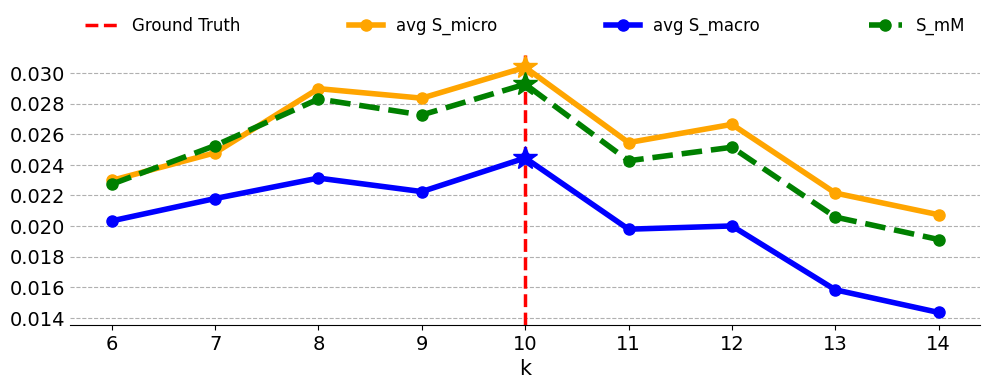


 K selected by S_mM: 10  | value at the ground-truth k:  0.029266426381941275

 K selected by subsample-average S_micro: 10  | value at the ground-truth k:  0.030367843620479108

 K selected by subsample-average S_macro: 10  | value at the ground-truth k:  0.02444888815865852

 K selected by mean (full-run) S_micro: 6  | value at the ground-truth k:  0.030392927303910255

 K selected by mean (full-run) S_macro: 6  | value at the ground-truth k:  0.022564606805681252

 K selected by mean (full-run) CH: 6  | value at the ground-truth k:  136.3792724609375

 K selected by mean (full-run) DB: 10  | value at the ground-truth k:  3.642359488022784


In [25]:
compsilhouette_stl = CompSil(
    data=X_stl,
    ground_truth=k_stl,
    k_values=range(6, 15),
    num_samples=10,
    sample_size="auto",
    random_state=42
)

compsilhouette_stl.evaluate()

df_stl = compsilhouette_stl.get_results_dataframe()
display(df_stl)

compsilhouette_stl.plot_results()

smm_k_stl, smm_val_stl = argmax_k_and_value_at_gt(df_stl, "S_mM", k_stl)
subavg_micro_k_stl, subavg_micro_val_stl = argmax_k_and_value_at_gt(df_stl, "avg S_micro", k_stl)
subavg_macro_k_stl, subavg_macro_val_stl = argmax_k_and_value_at_gt(df_stl, "avg S_macro", k_stl)

full_out_stl = mean_metrics_over_runs_choose_k(X=X_stl, num_runs=10, k_values=range(6, 15), random_state=42, kmeans_n_init=1, k_true=k_stl)

avg_micro_k_stl = full_out_stl["k_micro"]
avg_micro_val_stl = full_out_stl["mean_micro_at_k_micro"]

avg_macro_k_stl = full_out_stl["k_macro"]
avg_macro_val_stl = full_out_stl["mean_macro_at_k_macro"]

avg_ch_k_stl = full_out_stl["k_ch"]
avg_ch_val_stl = full_out_stl["mean_ch_at_k_ch"]

avg_db_k_stl = full_out_stl["k_db"]
avg_db_val_stl = full_out_stl["mean_db_at_k_db"]

print("\n K selected by S_mM:", smm_k_stl," | value at the ground-truth k: ",smm_val_stl)
print("\n K selected by subsample-average S_micro:", subavg_micro_k_stl," | value at the ground-truth k: ",subavg_micro_val_stl)
print("\n K selected by subsample-average S_macro:", subavg_macro_k_stl," | value at the ground-truth k: ",subavg_macro_val_stl)

print("\n K selected by mean (full-run) S_micro:", avg_micro_k_stl, " | value at the ground-truth k: ", avg_micro_val_stl)
print("\n K selected by mean (full-run) S_macro:", avg_macro_k_stl, " | value at the ground-truth k: ", avg_macro_val_stl)
print("\n K selected by mean (full-run) CH:",      avg_ch_k_stl,    " | value at the ground-truth k: ", avg_ch_val_stl)
print("\n K selected by mean (full-run) DB:",      avg_db_k_stl,    " | value at the ground-truth k: ", avg_db_val_stl)

results_main[name_stl] = {
    "k_true": k_stl,

    "k_SmM": smm_k_stl,
    "SmM": smm_val_stl,

    "k_subavg_micro": subavg_micro_k_stl,
    "subavg_micro": subavg_micro_val_stl,

    "k_subavg_macro": subavg_macro_k_stl,
    "subavg_macro": subavg_macro_val_stl,

    "k_avg_micro": avg_micro_k_stl,
    "avg_micro": avg_micro_val_stl,

    "k_avg_macro": avg_macro_k_stl,
    "avg_macro": avg_macro_val_stl,

    "k_avg_CH": avg_ch_k_stl,
    "avg_CH": avg_ch_val_stl,

    "k_avg_DB": avg_db_k_stl,
    "avg_DB": avg_db_val_stl,
}

### BBC News

,avg S_micro,avg S_macro,w_micro,S_mM,std S_mM,se S_mM,LCB S_mM,B_eff,sample_size,sample_fraction
k,,,,,,,,,,
2,0.076836,0.089541,0.344022,0.086678,0.014204,0.003176,0.083502,20,1335,0.6
3,0.082191,0.094808,0.319270,0.092399,0.011858,0.002651,0.089748,20,1335,0.6
4,0.095914,0.104672,0.275884,0.102724,0.005808,0.001299,0.101426,20,1335,0.6
5,0.107603,0.110500,0.439746,0.110215,0.003731,0.000834,0.109380,20,1335,0.6
6,0.108105,0.109675,0.471862,0.109684,0.004544,0.001016,0.108668,20,1335,0.6
7,0.106749,0.107651,0.450171,0.108201,0.007023,0.001570,0.106630,20,1335,0.6
8,0.102597,0.103669,0.423556,0.103862,0.006573,0.001470,0.102393,20,1335,0.6
9,0.100542,0.104268,0.429664,0.103199,0.008889,0.001988,0.101212,20,1335,0.6


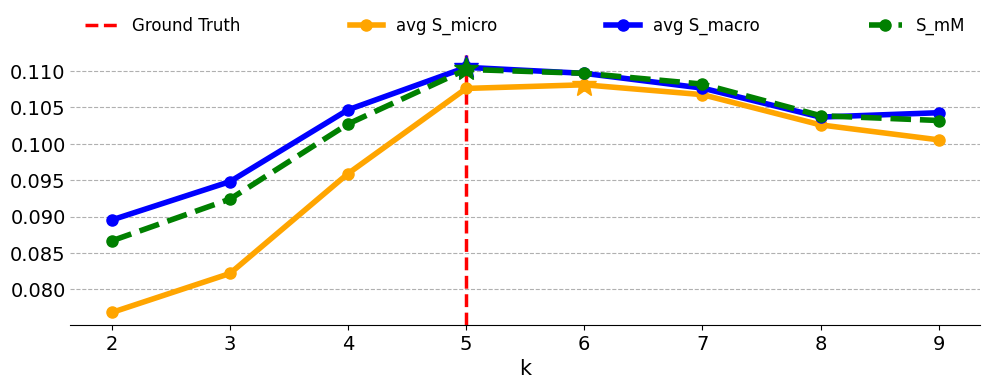


 K selected by S_mM: 5  | value at the ground-truth k:  0.110214830004011

 K selected by subsample-average S_micro: 6  | value at the ground-truth k:  0.10760347172617912

 K selected by subsample-average S_macro: 5  | value at the ground-truth k:  0.11049979904666543

 K selected by mean (full-run) S_micro: 5  | value at the ground-truth k:  0.1062277290970087

 K selected by mean (full-run) S_macro: 5  | value at the ground-truth k:  0.1088719749636948

 K selected by mean (full-run) CH: 2  | value at the ground-truth k:  158.79342193603514

 K selected by mean (full-run) DB: 7  | value at the ground-truth k:  2.6560740913437515


In [26]:
compsilhouette_bbc = CompSil(
    data=X_bbc,
    ground_truth=k_bbc,
    k_values=range(2,10),
    num_samples=20,
    sample_size="auto",
    random_state=0
)

compsilhouette_bbc.evaluate()

df_bbc = compsilhouette_bbc.get_results_dataframe()
display(df_bbc)

compsilhouette_bbc.plot_results()

smm_k_bbc, smm_val_bbc = argmax_k_and_value_at_gt(df_bbc, "S_mM", k_bbc)
subavg_micro_k_bbc, subavg_micro_val_bbc = argmax_k_and_value_at_gt(df_bbc, "avg S_micro", k_bbc)
subavg_macro_k_bbc, subavg_macro_val_bbc = argmax_k_and_value_at_gt(df_bbc, "avg S_macro", k_bbc)

full_out_bbc = mean_metrics_over_runs_choose_k(X=X_bbc, num_runs=20, k_values=range(2, 10), random_state=0, kmeans_n_init=1, k_true=k_bbc)

avg_micro_k_bbc = full_out_bbc["k_micro"]
avg_micro_val_bbc = full_out_bbc["mean_micro_at_k_micro"]

avg_macro_k_bbc = full_out_bbc["k_macro"]
avg_macro_val_bbc = full_out_bbc["mean_macro_at_k_macro"]

avg_ch_k_bbc = full_out_bbc["k_ch"]
avg_ch_val_bbc = full_out_bbc["mean_ch_at_k_ch"]

avg_db_k_bbc = full_out_bbc["k_db"]
avg_db_val_bbc = full_out_bbc["mean_db_at_k_db"]

print("\n K selected by S_mM:", smm_k_bbc," | value at the ground-truth k: ",smm_val_bbc)
print("\n K selected by subsample-average S_micro:", subavg_micro_k_bbc," | value at the ground-truth k: ",subavg_micro_val_bbc)
print("\n K selected by subsample-average S_macro:", subavg_macro_k_bbc," | value at the ground-truth k: ",subavg_macro_val_bbc)

print("\n K selected by mean (full-run) S_micro:", avg_micro_k_bbc, " | value at the ground-truth k: ", avg_micro_val_bbc)
print("\n K selected by mean (full-run) S_macro:", avg_macro_k_bbc, " | value at the ground-truth k: ", avg_macro_val_bbc)
print("\n K selected by mean (full-run) CH:",      avg_ch_k_bbc,    " | value at the ground-truth k: ", avg_ch_val_bbc)
print("\n K selected by mean (full-run) DB:",      avg_db_k_bbc,    " | value at the ground-truth k: ", avg_db_val_bbc)

results_main[name_bbc] = {
    "k_true": k_bbc,

    "k_SmM": smm_k_bbc,
    "SmM": smm_val_bbc,

    "k_subavg_micro": subavg_micro_k_bbc,
    "subavg_micro": subavg_micro_val_bbc,

    "k_subavg_macro": subavg_macro_k_bbc,
    "subavg_macro": subavg_macro_val_bbc,

    "k_avg_micro": avg_micro_k_bbc,
    "avg_micro": avg_micro_val_bbc,

    "k_avg_macro": avg_macro_k_bbc,
    "avg_macro": avg_macro_val_bbc,

    "k_avg_CH": avg_ch_k_bbc,
    "avg_CH": avg_ch_val_bbc,

    "k_avg_DB": avg_db_k_bbc,
    "avg_DB": avg_db_val_bbc,
}

### Minds-14

,avg S_micro,avg S_macro,w_micro,S_mM,std S_mM,se S_mM,LCB S_mM,B_eff,sample_size,sample_fraction
k,,,,,,,,,,
9,0.201269,0.247810,0.242699,0.237431,0.022377,0.007076,0.230355,10,539,1.0
10,0.217360,0.253859,0.178505,0.247656,0.013499,0.004269,0.243387,10,539,1.0
11,0.229926,0.261316,0.175407,0.256182,0.013874,0.004387,0.251794,10,539,1.0
12,0.245965,0.268711,0.167578,0.265157,0.013892,0.004393,0.260764,10,539,1.0
13,0.258214,0.268113,0.260033,0.266005,0.014684,0.004644,0.261362,10,539,1.0
14,0.268072,0.268120,0.509874,0.268919,0.012570,0.003975,0.264944,10,539,1.0
15,0.269365,0.261841,0.743724,0.268041,0.012184,0.003853,0.264189,10,539,1.0
16,0.263258,0.247152,0.811228,0.260457,0.013427,0.004246,0.256211,10,539,1.0
17,0.260703,0.237820,0.780790,0.256171,0.011774,0.003723,0.252447,10,539,1.0


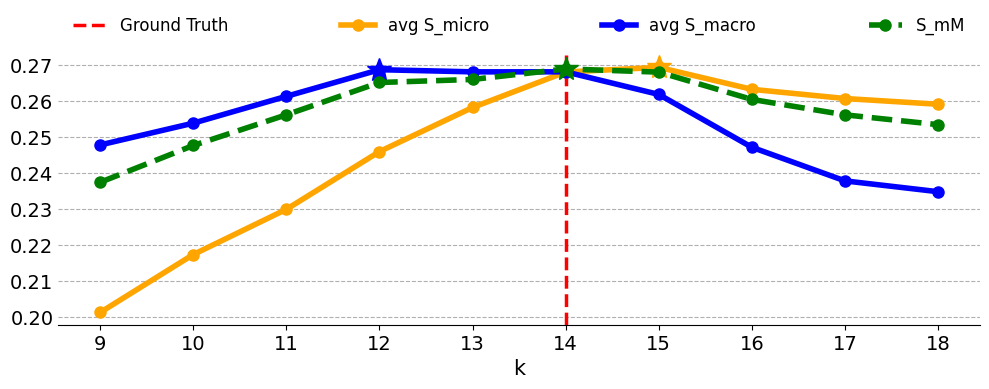


 K selected by S_mM: 14  | value at the ground-truth k:  0.2689186783702356

 K selected by subsample-average S_micro: 15  | value at the ground-truth k:  0.268071603174856

 K selected by subsample-average S_macro: 12  | value at the ground-truth k:  0.2681201503578422

 K selected by mean (full-run) S_micro: 15  | value at the ground-truth k:  0.26578879323251453

 K selected by mean (full-run) S_macro: 14  | value at the ground-truth k:  0.2654530715713458

 K selected by mean (full-run) CH: 14  | value at the ground-truth k:  45.63686389017155

 K selected by mean (full-run) DB: 14  | value at the ground-truth k:  1.702539366256568


In [27]:
compsilhouette_minds = CompSil(
    data=X_minds,
    ground_truth=k_minds,
    k_values=range(9,19),
    num_samples=10,
    sample_size="auto",
    random_state=0
)

compsilhouette_minds.evaluate()
df_minds = compsilhouette_minds.get_results_dataframe()
display(df_minds)
compsilhouette_minds.plot_results()

smm_k_minds, smm_val_minds = argmax_k_and_value_at_gt(df_minds, "S_mM", k_minds)
subavg_micro_k_minds, subavg_micro_val_minds = argmax_k_and_value_at_gt(df_minds, "avg S_micro", k_minds)
subavg_macro_k_minds, subavg_macro_val_minds = argmax_k_and_value_at_gt(df_minds, "avg S_macro", k_minds)

full_out_minds = mean_metrics_over_runs_choose_k(X=X_minds, num_runs=10, k_values=range(9, 19), random_state=0, kmeans_n_init=1, k_true=k_minds)

avg_micro_k_minds = full_out_minds["k_micro"]
avg_micro_val_minds = full_out_minds["mean_micro_at_k_micro"]

avg_macro_k_minds = full_out_minds["k_macro"]
avg_macro_val_minds = full_out_minds["mean_macro_at_k_macro"]

avg_ch_k_minds = full_out_minds["k_ch"]
avg_ch_val_minds = full_out_minds["mean_ch_at_k_ch"]

avg_db_k_minds = full_out_minds["k_db"]
avg_db_val_minds = full_out_minds["mean_db_at_k_db"]

print("\n K selected by S_mM:", smm_k_minds," | value at the ground-truth k: ",smm_val_minds)
print("\n K selected by subsample-average S_micro:", subavg_micro_k_minds," | value at the ground-truth k: ",subavg_micro_val_minds)
print("\n K selected by subsample-average S_macro:", subavg_macro_k_minds," | value at the ground-truth k: ",subavg_macro_val_minds)

print("\n K selected by mean (full-run) S_micro:", avg_micro_k_minds, " | value at the ground-truth k: ", avg_micro_val_minds)
print("\n K selected by mean (full-run) S_macro:", avg_macro_k_minds, " | value at the ground-truth k: ", avg_macro_val_minds)
print("\n K selected by mean (full-run) CH:",      avg_ch_k_minds,    " | value at the ground-truth k: ", avg_ch_val_minds)
print("\n K selected by mean (full-run) DB:",      avg_db_k_minds,    " | value at the ground-truth k: ", avg_db_val_minds)

results_main[name_minds] = {
    "k_true": k_minds,

    "k_SmM": smm_k_minds,
    "SmM": smm_val_minds,

    "k_subavg_micro": subavg_micro_k_minds,
    "subavg_micro": subavg_micro_val_minds,

    "k_subavg_macro": subavg_macro_k_minds,
    "subavg_macro": subavg_macro_val_minds,

    "k_avg_micro": avg_micro_k_minds,
    "avg_micro": avg_micro_val_minds,

    "k_avg_macro": avg_macro_k_minds,
    "avg_macro": avg_macro_val_minds,

    "k_avg_CH": avg_ch_k_minds,
    "avg_CH": avg_ch_val_minds,

    "k_avg_DB": avg_db_k_minds,
    "avg_DB": avg_db_val_minds,
}

### Banking77

,avg S_micro,avg S_macro,w_micro,S_mM,std S_mM,se S_mM,LCB S_mM,B_eff,sample_size,sample_fraction
k,,,,,,,,,,
72,0.164626,0.171798,0.236236,0.170246,0.004380,0.001385,0.168861,10,7849,0.599939
73,0.165332,0.171928,0.229531,0.170581,0.004838,0.001530,0.169051,10,7849,0.599939
74,0.165503,0.171854,0.252505,0.170484,0.003726,0.001178,0.169306,10,7849,0.599939
75,0.166759,0.172307,0.256611,0.171177,0.004215,0.001333,0.169844,10,7849,0.599939
76,0.166628,0.172503,0.274496,0.171180,0.004204,0.001329,0.169850,10,7849,0.599939
77,0.167189,0.173342,0.313100,0.171736,0.004035,0.001276,0.170460,10,7849,0.599939
78,0.166753,0.172642,0.321865,0.171066,0.003689,0.001167,0.169899,10,7849,0.599939
79,0.166542,0.171639,0.356845,0.170221,0.004347,0.001375,0.168847,10,7849,0.599939
80,0.166858,0.171855,0.349340,0.170441,0.004140,0.001309,0.169132,10,7849,0.599939


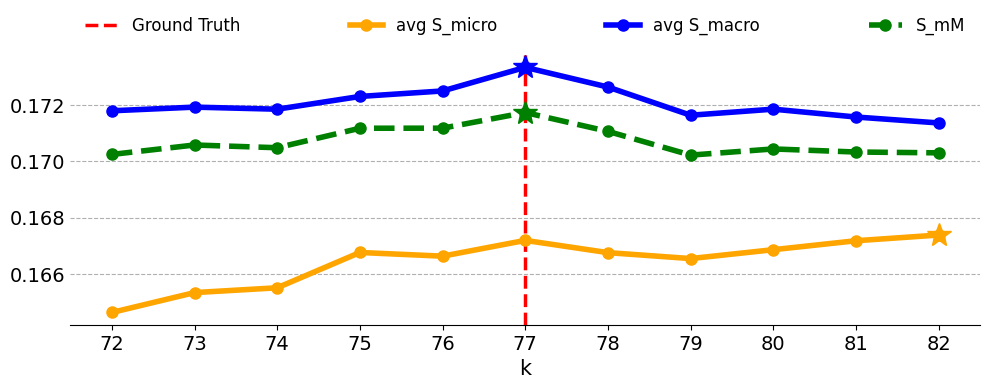


 K selected by S_mM: 77  | value at the ground-truth k:  0.17173579186282528

 K selected by subsample-average S_micro: 82  | value at the ground-truth k:  0.1671885682587409

 K selected by subsample-average S_macro: 77  | value at the ground-truth k:  0.1733423931992805

 K selected by mean (full-run) S_micro: 81  | value at the ground-truth k:  0.16579582210761223

 K selected by mean (full-run) S_macro: 77  | value at the ground-truth k:  0.17385240513841466

 K selected by mean (full-run) CH: 72  | value at the ground-truth k:  279.00156897539483

 K selected by mean (full-run) DB: 81  | value at the ground-truth k:  1.9736753737812163


In [28]:
compsilhouette_b77 = CompSil(
    data=X_b77,
    ground_truth=k_b77,
    k_values=range(72,83),
    num_samples=10,
    sample_size="auto",
    random_state=40
)

compsilhouette_b77.evaluate()
df_b77 = compsilhouette_b77.get_results_dataframe()
display(df_b77)
compsilhouette_b77.plot_results()


smm_k_b77, smm_val_b77 = argmax_k_and_value_at_gt(df_b77, "S_mM", k_b77)
subavg_micro_k_b77, subavg_micro_val_b77 = argmax_k_and_value_at_gt(df_b77, "avg S_micro", k_b77)
subavg_macro_k_b77, subavg_macro_val_b77 = argmax_k_and_value_at_gt(df_b77, "avg S_macro", k_b77)

full_out_b77 = mean_metrics_over_runs_choose_k(X=X_b77, num_runs=10, k_values=range(72, 83), random_state=40, kmeans_n_init=1, k_true=k_b77)

avg_micro_k_b77 = full_out_b77["k_micro"]
avg_micro_val_b77 = full_out_b77["mean_micro_at_k_micro"]

avg_macro_k_b77 = full_out_b77["k_macro"]
avg_macro_val_b77 = full_out_b77["mean_macro_at_k_macro"]

avg_ch_k_b77 = full_out_b77["k_ch"]
avg_ch_val_b77 = full_out_b77["mean_ch_at_k_ch"]

avg_db_k_b77 = full_out_b77["k_db"]
avg_db_val_b77 = full_out_b77["mean_db_at_k_db"]

print("\n K selected by S_mM:", smm_k_b77," | value at the ground-truth k: ",smm_val_b77)
print("\n K selected by subsample-average S_micro:", subavg_micro_k_b77," | value at the ground-truth k: ",subavg_micro_val_b77)
print("\n K selected by subsample-average S_macro:", subavg_macro_k_b77," | value at the ground-truth k: ",subavg_macro_val_b77)

print("\n K selected by mean (full-run) S_micro:", avg_micro_k_b77, " | value at the ground-truth k: ", avg_micro_val_b77)
print("\n K selected by mean (full-run) S_macro:", avg_macro_k_b77, " | value at the ground-truth k: ", avg_macro_val_b77)
print("\n K selected by mean (full-run) CH:",      avg_ch_k_b77,    " | value at the ground-truth k: ", avg_ch_val_b77)
print("\n K selected by mean (full-run) DB:",      avg_db_k_b77,    " | value at the ground-truth k: ", avg_db_val_b77)

results_main[name_b77] = {
    "k_true": k_b77,

    "k_SmM": smm_k_b77,
    "SmM": smm_val_b77,

    "k_subavg_micro": subavg_micro_k_b77,
    "subavg_micro": subavg_micro_val_b77,

    "k_subavg_macro": subavg_macro_k_b77,
    "subavg_macro": subavg_macro_val_b77,

    "k_avg_micro": avg_micro_k_b77,
    "avg_micro": avg_micro_val_b77,

    "k_avg_macro": avg_macro_k_b77,
    "avg_macro": avg_macro_val_b77,

    "k_avg_CH": avg_ch_k_b77,
    "avg_CH": avg_ch_val_b77,

    "k_avg_DB": avg_db_k_b77,
    "avg_DB": avg_db_val_b77,
}

### Results

In [29]:
results_df = pd.DataFrame.from_dict(results_main, orient="index")
results_df.index.name = "dataset"
display(results_df)

,k_true,k_SmM,SmM,k_subavg_micro,subavg_micro,k_subavg_macro,subavg_macro,k_avg_micro,avg_micro,k_avg_macro,avg_macro,k_avg_CH,avg_CH,k_avg_DB,avg_DB
dataset,,,,,,,,,,,,,,,
S1,5,5,0.872850,5,0.872739,5,0.872835,5,0.872835,5,0.872835,5,284172.512094,5,0.178116
S2,6,6,0.692430,6,0.692379,3,0.692283,6,0.692341,3,0.692395,6,62274.874761,6,0.429189
S3,5,3,0.675418,3,0.475706,3,0.706351,3,0.485110,5,0.725402,10,3869.820192,5,0.482930
S4,12,11,0.616828,8,0.414685,9,0.654004,9,0.412147,9,0.665234,16,6888.196391,9,0.498312
Pks,2,2,0.389172,2,0.404031,2,0.308322,2,0.412584,2,0.315685,3,96.118271,2,1.123987
Bld,2,2,0.261227,2,0.191575,2,0.275452,5,0.164393,2,0.270552,5,155.759101,2,1.377514
htr,2,2,0.427174,2,0.448854,2,0.278595,2,0.450041,2,0.279345,3,7378.472832,3,1.349514
Spm,2,2,0.144744,2,0.134989,2,0.131229,2,0.094802,2,0.102112,2,94.404613,2,3.814758
Bnk,2,2,0.294967,2,0.311070,2,0.231476,2,0.356534,2,0.248135,2,7565.292079,2,1.591655
